# Proyek Analisis Data: Nutri AI

## Pertanyaan Bisnis

- **Pertanyaan 1:**  Makanan apa saja yang paling efisien dalam memenuhi kebutuhan kalori dan protein harian (AKG) untuk individu usia 19–29 tahun, serta berapa porsi yang dibutuhkan untuk mencapainya?
- **Pertanyaan 2:** Seberapa banyak makanan dalam dataset yang memenuhi kebutuhan nutrisi berdasarkan standar AKG untuk perempuan usia 19-29 tahun pada kondisi masa menyusui (breastfeeding) 6 bulan pertama?
- **Pertanyaan 3:** Apakah makanan yang tinggi kalori juga cenderung memiliki persentase pemenuhan AKG protein yang tinggi untuk individu usia 19–29 tahun?
- **Pertanyaan 4:** Makanan apa saja yang memiliki skor tertinggi berdasarkan kandungan protein dan berapa persen pemenuhan kebutuhan protein pada wanita usia 19–29 tahun berdasarkan akg?
- **Pertanyaan 5:** Nutrisi apa yang paling sulit dipenuhi berdasarkan standar AKG perempuan usia 19–29 tahun jika hanya mengonsumsi satu jenis makanan?


## Import Semua Packages/Library yang Digunakan

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import requests
import os
import ast
import seaborn as sns
import re

## Data Wrangling

### Gathering Data

####Dataset AKG


In [2]:
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Memuat data angka kecukupan gizi sebagai acuan gizi harian
akg = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/Data/angka_kecukupan_gizi_dataset.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Dataset AKG diperoleh dari **PERATURAN MENTERI KESEHATAN REPUBLIK INDONESIA NOMOR 28 TAHUN 2019** tentang Angka Kecukupan Gizi yang Dianjurkan untuk Masyarakat Indonesia sebagai acuan resmi kebutuhan gizi masyarakat Indonesia berdasarkan usia dan kondisi tertentu.

#### Food 101 Dataset


In [5]:
# Muat data nutrisi awal yang bersih
food = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/Data/nutrition_table_internal.csv')

display(food.head())

,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,360.0,6.0,52.0,16.0,1.6,90.0,1.3,2.0
1,baby_back_ribs,300.0,22.0,28.0,18.0,2.0,80.0,2.5,5.0
2,baklava,360.0,6.0,52.0,16.0,1.6,90.0,1.3,2.0
3,beef_carpaccio,300.0,22.0,28.0,18.0,2.0,80.0,2.5,5.0
4,beef_tartare,300.0,22.0,28.0,18.0,2.0,80.0,2.5,5.0


#### Asal Data Nutrisi

Dataset nutrisi yang kita gunakan ini berasal dari Food101. Perlu dicatat bahwa dataset Food101 asli hanya berisi gambar makanan. Oleh karena itu, data nutrisi ini telah **dibuat secara generatif** untuk merepresentasikan informasi nutrisi yang relevan dengan kategori makanan yang ada di Food101.

Karena syarat proyek membutuhkan data yang tidak 'bersih' atau 'siap pakai', kami sengaja menambahkan berbagai jenis 'noise' (seperti *Gaussian noise*, *missing values*, *outliers*, dan duplikasi baris) ke dalam dataset ini. Hal ini bertujuan untuk mensimulasikan tantangan data dunia nyata dan menunjukkan proses pembersihan data yang komprehensif.

In [6]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   class_name     101 non-null    object 
 1   calories_kcal  101 non-null    float64
 2   protein_g      101 non-null    float64
 3   carbs_g        101 non-null    float64
 4   fat_g          101 non-null    float64
 5   fiber_g        101 non-null    float64
 6   calcium_mg     101 non-null    float64
 7   iron_mg        101 non-null    float64
 8   vitamin_c_mg   101 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.2+ KB


Langkah 1: Menambahkan *Gaussian Noise*

Kita akan memulai dengan menambahkan *Gaussian noise* ke kolom-kolom numerik dalam dataset. Ini mensimulasikan ketidakpastian atau variasi alami dalam pengukuran data, sambil tetap mempertahankan distribusi umum dari data asli.

*Gaussian noise* ditambahkan dengan menghitung standar deviasi (std dev) untuk setiap kolom numerik, kemudian menghasilkan noise acak berdasarkan 5% dari std dev tersebut. Penting untuk memastikan nilai-nilai setelah penambahan noise tidak kurang dari nol, terutama untuk metrik seperti kalori atau gram.

In [7]:
# Identifikasi kolom numerik
numerical_cols = food.select_dtypes(include=np.number).columns

# Tentukan tingkat noise (bisa disesuaikan)
noise_scale = 0.05 # 5% dari standar deviasi setiap kolom

# Buat salinan untuk ditambahkan noise, agar data asli yang bersih tetap utuh
food_noisy = food.copy()

for col in numerical_cols:
    # Hitung standar deviasi untuk kolom
    std_dev = food_noisy[col].std()
    # Hasilkan Gaussian noise berdasarkan std dev kolom dan skala yang diinginkan
    noise = np.random.normal(0, std_dev * noise_scale, food_noisy[col].shape)
    # Tambahkan noise ke kolom. Pastikan nilai tidak kurang dari nol jika merepresentasikan kuantitas.
    food_noisy[col] = food_noisy[col] + noise
    food_noisy[col] = food_noisy[col].apply(lambda x: max(0, x)) # Pastikan tidak ada nilai negatif setelah penambahan noise

print("Data dengan Gaussian noise:")
display(food_noisy.head())

Data dengan Gaussian noise:


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,1.996507
1,baby_back_ribs,302.040131,22.435123,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,15.741982,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


Langkah 2: Menambahkan *Missing Values*

Selanjutnya, kita akan menambahkan 'noise' berupa data yang hilang (*missing values* atau NaN) ke dalam `df_noisy`. Ini mensimulasikan skenario di mana beberapa data tidak terekam, lupa dicatat, atau hilang selama proses pengumpulan data. Untuk ini, 10% dari data numerik akan diatur menjadi NaN secara acak.

In [8]:
# Tentukan persentase data yang ingin dihilangkan (misalnya, 10%)
missing_data_percentage = 0.10

# Buat salinan lagi agar tidak merusak df_noisy sebelumnya
food_noisy_with_missing = food_noisy.copy()

# Untuk setiap kolom numerik, secara acak atur beberapa nilai menjadi NaN
for col in numerical_cols:
    # Pilih indeks secara acak untuk diatur menjadi NaN
    num_missing = int(len(food_noisy_with_missing) * missing_data_percentage)
    missing_indices = np.random.choice(food_noisy_with_missing.index, num_missing, replace=False)
    food_noisy_with_missing.loc[missing_indices, col] = np.nan

print(f"Data dengan noise Gaussian dan {missing_data_percentage*100}% missing values:")
display(food_noisy_with_missing.head())

print("\nJumlah missing values per kolom:")
display(food_noisy_with_missing.isnull().sum())

Data dengan noise Gaussian dan 10.0% missing values:


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,1.996507
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988



Jumlah missing values per kolom:


,0
class_name,0
calories_kcal,10
protein_g,10
carbs_g,10
fat_g,10
fiber_g,10
calcium_mg,10
iron_mg,10
vitamin_c_mg,10


Langkah 3: Menambahkan *Outliers*

Untuk membuat data lebih "acak" lagi, kita bisa memperkenalkan *outlier* (nilai ekstrem). Outlier adalah observasi yang secara signifikan berbeda dari observasi lain. Ini bisa mensimulasikan kesalahan pencatatan yang besar, *sensor malfunction*, atau kejadian yang tidak biasa. Kita akan secara acak memilih sel-sel dalam kolom numerik dan mengalikan nilainya dengan faktor besar (misalnya 5) atau menambahkan konstanta besar (misalnya 100) untuk menciptakan nilai ekstrem.

In [9]:
# Buat salinan dari df_noisy_with_missing
food_final_noisy = food_noisy_with_missing.copy()

# Tentukan persentase sel yang akan dijadikan outlier (misalnya, 1% dari total sel numerik)
outlier_percentage = 0.01

# Faktor untuk outlier (misalnya, nilai akan dikalikan 5 atau ditambahkan 100)
outlier_factor = 5
outlier_add_value = 100

# Hitung total sel numerik yang akan dijadikan outlier
total_numerical_cells = food_final_noisy[numerical_cols].size
num_outliers_to_add = int(total_numerical_cells * outlier_percentage)

print(f"Menambahkan {num_outliers_to_add} outlier ke data...")

# Untuk setiap outlier yang akan ditambahkan
for _ in range(num_outliers_to_add):
    # Pilih kolom numerik secara acak
    col_to_corrupt = np.random.choice(numerical_cols)

    # Pilih indeks baris secara acak
    row_to_corrupt = np.random.choice(food_final_noisy.index)

    # Pastikan sel yang dipilih bukan NaN (jika sudah NaN, lewati)
    if pd.notna(food_final_noisy.loc[row_to_corrupt, col_to_corrupt]):
        original_value = food_final_noisy.loc[row_to_corrupt, col_to_corrupt]
        # Tentukan apakah akan mengalikan atau menambahkan nilai untuk membuat outlier
        if np.random.rand() < 0.5: # 50% kemungkinan untuk mengalikan
            new_value = original_value * outlier_factor
        else: # 50% kemungkinan untuk menambahkan
            new_value = original_value + outlier_add_value

        food_final_noisy.loc[row_to_corrupt, col_to_corrupt] = new_value

print("Data dengan noise Gaussian, missing values, dan outliers:")
display(food_final_noisy.head())

print("\nRingkasan statistik data akhir dengan semua jenis noise:")
display(food_final_noisy.describe())

Menambahkan 8 outlier ke data...
Data dengan noise Gaussian, missing values, dan outliers:


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988



Ringkasan statistik data akhir dengan semua jenis noise:


,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,279.391672,13.600029,36.205138,12.860109,2.149964,90.035453,1.803840,8.370928
std,55.712764,13.354305,13.811803,3.525082,1.026031,26.556356,0.344339,16.946111
min,178.084677,5.284245,24.419260,9.685214,1.541046,76.978113,1.281634,1.451645
25%,239.575803,9.460264,27.830174,9.998782,1.939381,79.547603,1.776316,4.452228
50%,260.474322,10.000229,28.961909,10.159022,1.996108,80.846814,1.798649,4.895362
75%,331.012573,20.537823,38.644296,16.144662,2.027031,88.591357,1.816956,5.297727
max,365.265642,122.082672,128.291020,18.287373,10.078222,183.246533,2.513087,125.261935


Langkah 4: Menambahkan Baris Duplikat

Salah satu masalah umum lainnya dalam dataset adalah adanya duplikasi baris. Untuk membuat data Anda semakin menantang untuk pemrosesan AI, mari kita tambahkan beberapa baris duplikat secara acak. Ini mensimulasikan kesalahan *entry data* atau penggabungan dataset yang tidak sempurna.

In [10]:
# Buat salinan dari df_final_noisy
food_final_noisy_with_duplicates = food_final_noisy.copy()

# Tentukan persentase baris yang ingin diduplikasi (misalnya, 10% dari total baris)
duplication_percentage = 0.10

# Hitung berapa banyak baris yang akan diduplikasi
num_rows_to_duplicate = int(len(food_final_noisy) * duplication_percentage)

# Pilih indeks baris secara acak untuk diduplikasi
rows_to_duplicate_indices = np.random.choice(food_final_noisy.index, num_rows_to_duplicate, replace=True)

# Ambil baris-baris tersebut
duplicated_rows = food_final_noisy.loc[rows_to_duplicate_indices]

# Gabungkan baris duplikat kembali ke DataFrame
food_final_noisy_with_duplicates = pd.concat([food_final_noisy_with_duplicates, duplicated_rows], ignore_index=True)

print(f"Data dengan noise Gaussian, missing values, outliers, dan {duplication_percentage*100}% duplikasi baris:")
print(f"Jumlah baris awal: {len(food_final_noisy)}")
print(f"Jumlah baris setelah duplikasi: {len(food_final_noisy_with_duplicates)}")

display(food_final_noisy_with_duplicates.head())

Data dengan noise Gaussian, missing values, outliers, dan 10.0% duplikasi baris:
Jumlah baris awal: 101
Jumlah baris setelah duplikasi: 111


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


**Insight:**
- Dataset akg : berisi data angka kecukupan gizi harian
- Dataset df : berisi data nutrisi makanan dengan data yang telah ditambahkan berbagai jenis 'noise' (seperti Gaussian noise, missing values, outliers, dan duplikasi baris) untuk dapat dilakukan proses cleaning.

### Assessing Data


####Dataset AKG


In [11]:
akg.head()

,kategori_umur,kelompok_umur,berat_badan(kg),tinggi_badan(kg),energi(kkal),protein(g),lemak_total(g),omega3(g),omega6(g),karbohidrat(g),...,iodium(mcg),seng3(mg),selenium(mcg),mangan(mg),fluor(mg),kromium(mcg),kalium(mg),natrium(mg),klor(mg),tembaga(mcg)
0,bayi_anak,0-5 bulan,6.0,60.0,550,9,31.0,0.5,4.4,59,...,90,1.1,7,3.0,0.01,0.2,400,120,180,200
1,bayi_anak,6-11 bulan,9.0,72.0,800,15,35.0,0.5,4.4,105,...,120,3.0,10,0.7,0.50,6.0,700,370,570,220
2,bayi_anak,1-3 tahun,13.0,92.0,1350,20,45.0,0.7,7.0,215,...,90,3.0,18,1.2,0.70,14.0,2600,800,1200,340
3,bayi_anak,4-6 tahun,19.0,113.0,1400,25,50.0,0.9,10.0,220,...,120,5.0,21,1.5,1.00,16.0,2700,900,1300,440
4,bayi_anak,7-9 tahun,27.0,130.0,1650,40,55.0,0.9,10.0,250,...,120,5.0,22,1.7,1.40,21.0,3200,1000,1500,570


In [12]:
akg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kategori_umur     26 non-null     object 
 1   kelompok_umur     26 non-null     object 
 2   berat_badan(kg)   21 non-null     float64
 3   tinggi_badan(kg)  21 non-null     float64
 4   energi(kkal)      26 non-null     int64  
 5   protein(g)        26 non-null     int64  
 6   lemak_total(g)    26 non-null     float64
 7   omega3(g)         26 non-null     float64
 8   omega6(g)         26 non-null     float64
 9   karbohidrat(g)    26 non-null     int64  
 10  serat(g)          26 non-null     int64  
 11  air(ml)           26 non-null     int64  
 12  vitA(RE)          26 non-null     int64  
 13  vitD(mcg          26 non-null     int64  
 14  vitE(mcg)         26 non-null     int64  
 15  vitK(mcg)         26 non-null     int64  
 16  vitB1(mg)         26 non-null     float64
 17 

In [13]:
akg.isna().sum()

,0
kategori_umur,0
kelompok_umur,0
berat_badan(kg),5
tinggi_badan(kg),5
energi(kkal),0
protein(g),0
lemak_total(g),0
omega3(g),0
omega6(g),0
karbohidrat(g),0


In [14]:
akg.describe()

,berat_badan(kg),tinggi_badan(kg),energi(kkal),protein(g),lemak_total(g),omega3(g),omega6(g),karbohidrat(g),serat(g),air(ml),...,iodium(mcg),seng3(mg),selenium(mcg),mangan(mg),fluor(mg),kromium(mcg),kalium(mg),natrium(mg),klor(mg),tembaga(mcg)
count,21.000000,21.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,...,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,44.142857,143.904762,1548.461538,45.538462,47.011538,0.996154,9.800000,234.192308,21.461538,1594.230769,...,129.615385,7.273077,20.807692,1.623077,2.085000,21.776923,3303.846154,972.692308,1515.384615,635.961538
std,18.366507,32.183699,795.681807,23.267541,25.903163,0.489474,5.002719,127.355257,11.600796,741.798749,...,28.492914,3.186667,9.208775,0.740976,1.543143,10.788783,1990.071510,607.022620,873.353220,304.972193
min,6.000000,60.000000,180.000000,1.000000,2.200000,0.200000,2.000000,25.000000,0.000000,300.000000,...,70.000000,1.100000,5.000000,0.200000,0.000000,0.200000,0.000000,0.000000,0.000000,100.000000
25%,36.000000,145.000000,937.500000,21.250000,36.250000,0.550000,5.050000,128.750000,13.000000,962.500000,...,120.000000,5.000000,12.000000,1.275000,0.550000,16.750000,1175.000000,477.500000,727.500000,400.000000
50%,53.000000,158.000000,1725.000000,58.000000,50.000000,1.100000,11.000000,262.500000,24.000000,1725.000000,...,150.000000,8.000000,24.000000,1.800000,2.450000,22.500000,4700.000000,1150.000000,1900.000000,747.500000
75%,58.000000,164.000000,2137.500000,64.750000,65.000000,1.500000,13.500000,330.000000,29.750000,2262.500000,...,150.000000,10.500000,28.250000,2.275000,3.000000,29.000000,4700.000000,1500.000000,2250.000000,900.000000
max,60.000000,168.000000,2650.000000,75.000000,85.000000,1.600000,17.000000,430.000000,37.000000,2500.000000,...,150.000000,11.000000,36.000000,3.000000,4.000000,41.000000,5300.000000,1700.000000,2500.000000,900.000000


In [15]:
print("Jumlah duplikasi: ", akg.duplicated().sum())

Jumlah duplikasi:  0


####Dataset Nutrisi Makanan

In [16]:
food_final_noisy_with_duplicates.head()

,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


In [17]:
food_final_noisy_with_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   class_name     111 non-null    object 
 1   calories_kcal  101 non-null    float64
 2   protein_g      100 non-null    float64
 3   carbs_g        101 non-null    float64
 4   fat_g          98 non-null     float64
 5   fiber_g        101 non-null    float64
 6   calcium_mg     101 non-null    float64
 7   iron_mg        100 non-null    float64
 8   vitamin_c_mg   101 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.9+ KB


In [18]:
food_final_noisy_with_duplicates.isna().sum()

,0
class_name,0
calories_kcal,10
protein_g,11
carbs_g,10
fat_g,13
fiber_g,10
calcium_mg,10
iron_mg,11
vitamin_c_mg,10


In [19]:
food_final_noisy_with_duplicates.describe()

,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
count,101.000000,100.000000,101.000000,98.000000,101.000000,101.000000,100.000000,101.000000
mean,281.405070,13.350771,36.664493,12.904683,2.116414,90.511196,1.783066,7.973055
std,56.324028,12.878827,13.646621,3.487893,0.980947,26.783286,0.342975,16.139164
min,178.084677,5.284245,24.419260,9.685214,1.541046,76.978113,1.281634,1.451645
25%,239.484109,9.339378,27.830451,10.012111,1.660330,79.560346,1.764984,4.428646
50%,260.474322,10.008467,29.004910,10.161010,1.996108,81.058801,1.796980,4.874798
75%,334.385167,20.440013,51.012970,16.119193,2.026633,89.453294,1.815764,5.320826
max,365.265642,122.082672,128.291020,18.287373,10.078222,183.246533,2.513087,125.261935


In [20]:
print("Jumlah duplikasi: ", food_final_noisy_with_duplicates.duplicated().sum())

Jumlah duplikasi:  10


####Insight

*AKG Dataset (akg)*
- Hapus kolom nutrisi yang tidak dipakai
- Pisahkan kolom kelompok umur dalam rentang usia menjadi min_usia dan max_usia.
- Rename nama kolom sesuai dengan penamaan nutrisi yang ada di dataset food nutrition.
- Pisahkan data hamil dan menyusui karena merupakan informasi gizi tambahan dari wanita.
- Mengubah tipe data numerik menjadi float keseluruhan.

*Dataset Nutrisi Makanan (Food)*
- Menangani noise pada data numerik
- Menghapus atau menangani data duplikat
- Menangani missing value pada kolom numerik
- Mengidentifikasi dan menangani outlier pada data


###Cleaning Data


####Dataset AKG

In [21]:
akg_clean = akg.copy()

In [22]:
# drop kolom yang tidak dibutuhkan
akg_clean = akg.copy()

drop_cols = [
    "air(ml)",
    "vitA(RE)",
    "vitD(mcg",
    "vitE(mcg)",
    "vitK(mcg)",
    "vitB1(mg)",
    "vitB2(mg)",
    "vitB3(mg)",
    "vitB6(mg)",
    "folat(mcg)",
    "vitB12(mcg)",
    "biotin(mcg)",
    "kolin(mg)",
    "fosfor(mg)",
    "magnesium(mg)",
    "iodium(mcg)",
    "seng3(mg)",
    "selenium(mcg)",
    "mangan(mg)",
    "fluor(mg)",
    "kromium(mcg)",
    "kalium(mg)",
    "natrium(mg)",
    "klor(mg)",
    "tembaga(mcg)",
    "omega3(g)",
    "omega6(g)",
    "vitB5(mg)"
]

akg_clean = akg_clean.drop(columns=drop_cols)

In [23]:
akg_clean

,kategori_umur,kelompok_umur,berat_badan(kg),tinggi_badan(kg),energi(kkal),protein(g),lemak_total(g),karbohidrat(g),serat(g),vitC(mg),kalsium(mg),besi2(mg)
0,bayi_anak,0-5 bulan,6.0,60.0,550,9,31.0,59,0,40,200,0.3
1,bayi_anak,6-11 bulan,9.0,72.0,800,15,35.0,105,11,50,270,11.0
2,bayi_anak,1-3 tahun,13.0,92.0,1350,20,45.0,215,19,40,650,7.0
3,bayi_anak,4-6 tahun,19.0,113.0,1400,25,50.0,220,20,45,1000,10.0
4,bayi_anak,7-9 tahun,27.0,130.0,1650,40,55.0,250,23,45,1000,10.0
5,laki_laki,10-12 tahun,36.0,145.0,2000,50,65.0,300,28,50,1200,8.0
6,laki_laki,13-15 tahun,50.0,163.0,2400,70,80.0,350,34,75,1200,11.0
7,laki_laki,16-18 tahun,60.0,168.0,2650,75,85.0,400,37,90,1200,11.0
8,laki_laki,19-29 tahun,60.0,168.0,2650,65,75.0,430,37,90,1000,9.0
9,laki_laki,30-49 tahun,60.0,166.0,2550,65,70.0,415,36,90,1000,9.0


In [24]:
# 1. Parse age_group

def parse_age_group(value):
    value = str(value).lower().strip()
    numbers = list(map(int, re.findall(r"\d+", value)))

    # age group in months
    if "bulan" in value or "bln" in value:
        if len(numbers) >= 2:
            return numbers[0] / 12, numbers[1] / 12
        elif len(numbers) == 1:
            return 0, numbers[0] / 12
        return np.nan, np.nan

    # 80+ years
    if "+" in value and len(numbers) >= 1:
        return numbers[0], 100

    # normal range, e.g. 19-29 tahun
    if len(numbers) >= 2:
        return numbers[0], numbers[1]

    return np.nan, np.nan


akg_clean[["min_age", "max_age"]] = akg_clean["kelompok_umur"].apply(
    lambda x: pd.Series(parse_age_group(x))
)

# rename kolom

rename_dict = {
    "kategori_umur": "age_category",
    "kelompok_umur": "age_group",
    "berat_badan(kg)": "body_weight",
    "tinggi_badan(kg)": "height",
    "energi(kkal)": "calories_kcal",
    "protein(g)": "protein_g",
    "lemak_total(g)": "fat_g",
    "karbohidrat(g)": "carbs_g",
    "vitC(mg)": "vitamin_c_mg",
    "serat(g)": "fiber_g",
    "besi2(mg)":"iron_mg",
    "kalsium(mg)":"calcium_mg",
}

akg_clean = akg_clean.rename(columns=rename_dict)

# rename baris

category_map = {
    "bayi_anak": "infants_children",
    "laki_laki": "male",
    "perempuan": "female",
    "hamil": "pregnant",
    "menyusui": "breastfeeding",
}

age_group_map = {
    "0-5 bulan": "0-5 months",
    "6-11 bulan": "6-11 months",
    "1-3 tahun": "1-3 years",
    "4-6 tahun": "4-6 years",
    "7-9 tahun": "7-9 years",
    "10-12 tahun": "10-12 years",
    "13-15 tahun": "13-15 years",
    "16-18 tahun": "16-18 years",
    "19-29 tahun": "19-29 years",
    "30-49 tahun": "30-49 years",
    "50-64 tahun": "50-64 years",
    "65-80 tahun": "65-80 years",
    "80+ tahun": "80+ years",
    "trimester 1": "trimester 1",
    "trimester 2": "trimester 2",
    "trimester 3": "trimester 3",
    "6 bln pertama": "first 6 months",
    "6 bln kedua": "second 6 months",
}

akg_clean["age_category"] = akg_clean["age_category"].replace(category_map)
akg_clean["age_group"] = akg_clean["age_group"].replace(age_group_map)

# konversi kolom numeric

exclude_cols = ["age_category", "age_group"]

for col in akg_clean.columns:
    if col not in exclude_cols:
        akg_clean[col] = pd.to_numeric(akg_clean[col], errors="coerce")

# reorder kolomnya

front_cols = [
    "age_category",
    "age_group",
    "min_age",
    "max_age",
    "body_weight",
    "height",
    "calories_kcal",
    "protein_g",
    "fat_g",
    "carbs_g",
    "vitamin_c_mg",
    "fiber_g",
    "iron_mg",
    "calcium_mg",

]

other_cols = [col for col in akg_clean.columns if col not in front_cols]

akg_clean = akg_clean[front_cols + other_cols]

# lihat hasilnya

print("Shape:", akg_clean.shape)
print("\nMissing values:")
print(akg_clean.isnull().sum())

akg_clean.head()

Shape: (26, 14)

Missing values:
age_category     0
age_group        0
min_age          3
max_age          3
body_weight      5
height           5
calories_kcal    0
protein_g        0
fat_g            0
carbs_g          0
vitamin_c_mg     0
fiber_g          0
iron_mg          0
calcium_mg       0
dtype: int64


,age_category,age_group,min_age,max_age,body_weight,height,calories_kcal,protein_g,fat_g,carbs_g,vitamin_c_mg,fiber_g,iron_mg,calcium_mg
0,infants_children,0-5 months,0.0,0.416667,6.0,60.0,550,9,31.0,59,40,0,0.3,200
1,infants_children,6-11 months,0.5,0.916667,9.0,72.0,800,15,35.0,105,50,11,11.0,270
2,infants_children,1-3 years,1.0,3.000000,13.0,92.0,1350,20,45.0,215,40,19,7.0,650
3,infants_children,4-6 years,4.0,6.000000,19.0,113.0,1400,25,50.0,220,45,20,10.0,1000
4,infants_children,7-9 years,7.0,9.000000,27.0,130.0,1650,40,55.0,250,45,23,10.0,1000


In [25]:
# Feature engineering untuk kondisi khusus (pregnant & breastfeeding)

# Mengubah trimester kehamilan menjadi range bulan
# Tujuannya agar model bisa memahami tahap kehamilan dalam bentuk numerik (bukan string)
# Range digunakan karena kehamilan bersifat interval, bukan nilai pasti

akg_clean["preg_month_min"] = akg_clean["age_group"].map({
    "trimester 1": 0,
    "trimester 2": 4,
    "trimester 3": 7
})

akg_clean["preg_month_max"] = akg_clean["age_group"].map({
    "trimester 1": 3,
    "trimester 2": 6,
    "trimester 3": 9
})

# Merepresentasikan durasi menyusui (0–6 bulan dan 7–12 bulan)
akg_clean["bf_month_min"] = akg_clean["age_group"].map({
    "first 6 months": 0,
    "second 6 months": 7
})

akg_clean["bf_month_max"] = akg_clean["age_group"].map({
    "first 6 months": 6,
    "second 6 months": 12
})

# isi age untuk kondisi khusus
akg_clean.loc[akg_clean["age_category"].isin(["pregnant", "breastfeeding"]),
       ["min_age", "max_age"]] = [13, 49]

akg_clean[["preg_month_min", "preg_month_max",
    "bf_month_min", "bf_month_max"]] = akg_clean[[
    "preg_month_min", "preg_month_max",
    "bf_month_min", "bf_month_max"
]].fillna(0)

In [26]:
#Mengubah tipe data kolom nutrisi menjadi float
cols_float = [
    "calories_kcal",
    "protein_g",
    "fat_g",
    "carbs_g",
    "vitamin_c_mg",
    "fiber_g",
    "iron_mg",
    "calcium_mg"
]

akg_clean[cols_float] = akg_clean[cols_float].astype(float)

In [27]:
akg_clean

,age_category,age_group,min_age,max_age,body_weight,height,calories_kcal,protein_g,fat_g,carbs_g,vitamin_c_mg,fiber_g,iron_mg,calcium_mg,preg_month_min,preg_month_max,bf_month_min,bf_month_max
0,infants_children,0-5 months,0.0,0.416667,6.0,60.0,550.0,9.0,31.0,59.0,40.0,0.0,0.3,200.0,0.0,0.0,0.0,0.0
1,infants_children,6-11 months,0.5,0.916667,9.0,72.0,800.0,15.0,35.0,105.0,50.0,11.0,11.0,270.0,0.0,0.0,0.0,0.0
2,infants_children,1-3 years,1.0,3.000000,13.0,92.0,1350.0,20.0,45.0,215.0,40.0,19.0,7.0,650.0,0.0,0.0,0.0,0.0
3,infants_children,4-6 years,4.0,6.000000,19.0,113.0,1400.0,25.0,50.0,220.0,45.0,20.0,10.0,1000.0,0.0,0.0,0.0,0.0
4,infants_children,7-9 years,7.0,9.000000,27.0,130.0,1650.0,40.0,55.0,250.0,45.0,23.0,10.0,1000.0,0.0,0.0,0.0,0.0
5,male,10-12 years,10.0,12.000000,36.0,145.0,2000.0,50.0,65.0,300.0,50.0,28.0,8.0,1200.0,0.0,0.0,0.0,0.0
6,male,13-15 years,13.0,15.000000,50.0,163.0,2400.0,70.0,80.0,350.0,75.0,34.0,11.0,1200.0,0.0,0.0,0.0,0.0
7,male,16-18 years,16.0,18.000000,60.0,168.0,2650.0,75.0,85.0,400.0,90.0,37.0,11.0,1200.0,0.0,0.0,0.0,0.0
8,male,19-29 years,19.0,29.000000,60.0,168.0,2650.0,65.0,75.0,430.0,90.0,37.0,9.0,1000.0,0.0,0.0,0.0,0.0
9,male,30-49 years,30.0,49.000000,60.0,166.0,2550.0,65.0,70.0,415.0,90.0,36.0,9.0,1000.0,0.0,0.0,0.0,0.0


In [28]:
akg_normal = akg_clean[akg_clean["age_category"].isin(["infants_children", "male", "female"])]

akg_pregnant = akg_clean[akg_clean["age_category"] == "pregnant"]

akg_breastfeeding = akg_clean[akg_clean["age_category"] == "breastfeeding"]

In [29]:
akg_normal

,age_category,age_group,min_age,max_age,body_weight,height,calories_kcal,protein_g,fat_g,carbs_g,vitamin_c_mg,fiber_g,iron_mg,calcium_mg,preg_month_min,preg_month_max,bf_month_min,bf_month_max
0,infants_children,0-5 months,0.0,0.416667,6.0,60.0,550.0,9.0,31.0,59.0,40.0,0.0,0.3,200.0,0.0,0.0,0.0,0.0
1,infants_children,6-11 months,0.5,0.916667,9.0,72.0,800.0,15.0,35.0,105.0,50.0,11.0,11.0,270.0,0.0,0.0,0.0,0.0
2,infants_children,1-3 years,1.0,3.000000,13.0,92.0,1350.0,20.0,45.0,215.0,40.0,19.0,7.0,650.0,0.0,0.0,0.0,0.0
3,infants_children,4-6 years,4.0,6.000000,19.0,113.0,1400.0,25.0,50.0,220.0,45.0,20.0,10.0,1000.0,0.0,0.0,0.0,0.0
4,infants_children,7-9 years,7.0,9.000000,27.0,130.0,1650.0,40.0,55.0,250.0,45.0,23.0,10.0,1000.0,0.0,0.0,0.0,0.0
5,male,10-12 years,10.0,12.000000,36.0,145.0,2000.0,50.0,65.0,300.0,50.0,28.0,8.0,1200.0,0.0,0.0,0.0,0.0
6,male,13-15 years,13.0,15.000000,50.0,163.0,2400.0,70.0,80.0,350.0,75.0,34.0,11.0,1200.0,0.0,0.0,0.0,0.0
7,male,16-18 years,16.0,18.000000,60.0,168.0,2650.0,75.0,85.0,400.0,90.0,37.0,11.0,1200.0,0.0,0.0,0.0,0.0
8,male,19-29 years,19.0,29.000000,60.0,168.0,2650.0,65.0,75.0,430.0,90.0,37.0,9.0,1000.0,0.0,0.0,0.0,0.0
9,male,30-49 years,30.0,49.000000,60.0,166.0,2550.0,65.0,70.0,415.0,90.0,36.0,9.0,1000.0,0.0,0.0,0.0,0.0


In [30]:
akg_pregnant

,age_category,age_group,min_age,max_age,body_weight,height,calories_kcal,protein_g,fat_g,carbs_g,vitamin_c_mg,fiber_g,iron_mg,calcium_mg,preg_month_min,preg_month_max,bf_month_min,bf_month_max
21,pregnant,trimester 1,13.0,49.0,NaN,NaN,180.0,1.0,2.3,25.0,10.0,3.0,0.0,200.0,0.0,3.0,0.0,0.0
22,pregnant,trimester 2,13.0,49.0,NaN,NaN,300.0,10.0,2.3,40.0,10.0,4.0,9.0,200.0,4.0,6.0,0.0,0.0
23,pregnant,trimester 3,13.0,49.0,NaN,NaN,300.0,30.0,2.3,40.0,10.0,4.0,9.0,200.0,7.0,9.0,0.0,0.0


In [31]:
akg_breastfeeding

,age_category,age_group,min_age,max_age,body_weight,height,calories_kcal,protein_g,fat_g,carbs_g,vitamin_c_mg,fiber_g,iron_mg,calcium_mg,preg_month_min,preg_month_max,bf_month_min,bf_month_max
24,breastfeeding,first 6 months,13.0,49.0,NaN,NaN,330.0,20.0,2.2,45.0,45.0,5.0,0.0,200.0,0.0,0.0,0.0,6.0
25,breastfeeding,second 6 months,13.0,49.0,NaN,NaN,400.0,15.0,2.2,55.0,45.0,6.0,0.0,200.0,0.0,0.0,7.0,12.0


In [32]:
akg_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age_category    26 non-null     object 
 1   age_group       26 non-null     object 
 2   min_age         26 non-null     float64
 3   max_age         26 non-null     float64
 4   body_weight     21 non-null     float64
 5   height          21 non-null     float64
 6   calories_kcal   26 non-null     float64
 7   protein_g       26 non-null     float64
 8   fat_g           26 non-null     float64
 9   carbs_g         26 non-null     float64
 10  vitamin_c_mg    26 non-null     float64
 11  fiber_g         26 non-null     float64
 12  iron_mg         26 non-null     float64
 13  calcium_mg      26 non-null     float64
 14  preg_month_min  26 non-null     float64
 15  preg_month_max  26 non-null     float64
 16  bf_month_min    26 non-null     float64
 17  bf_month_max    26 non-null     float

####Dataset Food 101

In [33]:
# Assign data yang sudah berisik ke DataFrame baru untuk cleaning
food_cleaned = food_final_noisy_with_duplicates.copy()

print("Data awal untuk cleaning (dengan duplikat):")
print(f"Jumlah baris: {len(food_cleaned)}")
display(food_cleaned.head())

Data awal untuk cleaning (dengan duplikat):
Jumlah baris: 111


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


In [34]:
print("Jumlah baris duplikat:", food_cleaned.duplicated().sum())
print("\nBaris-baris duplikat (jika ada, berdasarkan semua kolom):")
display(food_cleaned[food_cleaned.duplicated()])

Jumlah baris duplikat: 10

Baris-baris duplikat (jika ada, berdasarkan semua kolom):


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
101,shrimp_and_grits,236.060982,21.216975,28.281441,NaN,2.018710,80.846814,1.781512,5.320826
102,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
103,ceviche,238.710140,10.051660,27.612173,10.060049,1.999594,78.932577,1.783591,4.568654
104,chocolate_mousse,358.732449,NaN,51.012970,16.184945,1.542431,88.195596,NaN,2.392803
105,shrimp_and_grits,236.060982,21.216975,28.281441,NaN,2.018710,80.846814,1.781512,5.320826
106,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
107,chocolate_cake,355.408766,6.124862,51.649325,15.840931,1.581029,91.188281,1.307484,1.861720
108,french_onion_soup,239.868999,10.022248,27.830451,9.975482,2.027753,78.732247,1.795023,5.479920
109,french_toast,354.794664,6.452596,52.218897,16.104353,1.660330,89.871355,1.304733,2.060277
110,lasagna,257.165881,10.626817,37.904040,10.361383,2.032158,178.694835,1.815652,4.658015


In [35]:
# Menghapus duplikasi baris
food_cleaned.drop_duplicates(inplace=True)

print(f"Jumlah baris setelah menghapus duplikat: {len(food_cleaned)}")
display(food_cleaned.head())

Jumlah baris setelah menghapus duplikat: 101


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,NaN,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,NaN,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


In [36]:
# Periksa kembali missing values
print("Missing values sebelum imputasi:")
display(food_cleaned.isnull().sum())

# Imputasi missing values di kolom numerik dengan median
for col in numerical_cols:
    if col in food_cleaned.columns and food_cleaned[col].isnull().any():
        median_val = food_cleaned[col].median()
        food_cleaned[col] = food_cleaned[col].fillna(median_val)

print("\nMissing values setelah imputasi:")
display(food_cleaned.isnull().sum())
display(food_cleaned.head())

Missing values sebelum imputasi:


,0
class_name,0
calories_kcal,10
protein_g,10
carbs_g,10
fat_g,10
fiber_g,10
calcium_mg,10
iron_mg,10
vitamin_c_mg,10



Missing values setelah imputasi:


,0
class_name,0
calories_kcal,0
protein_g,0
carbs_g,0
fat_g,0
fiber_g,0
calcium_mg,0
iron_mg,0
vitamin_c_mg,0


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,5.844512,51.276003,15.861857,1.650318,90.699417,1.301790,9.982535
1,baby_back_ribs,302.040131,10.000229,27.916557,17.720871,1.989340,80.476947,2.497126,5.588010
2,baklava,360.895629,5.917816,52.379504,10.159022,1.580057,90.396650,1.285848,1.878475
3,beef_carpaccio,303.289101,22.690291,27.591052,17.879225,1.950761,80.456593,2.491128,5.174073
4,beef_tartare,298.474040,21.913169,28.216052,17.952573,1.980968,78.653373,2.482732,5.515988


In [37]:
# Penanganan Outliers (menggunakan metode IQR capping)
# Kita akan membatasi nilai yang berada di luar 1.5 * IQR dari Q1 dan Q3

for col in numerical_cols:
    if col in food_cleaned.columns:
        Q1 = food_cleaned[col].quantile(0.25)
        Q3 = food_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Terapkan capping, pastikan nilai tidak menjadi negatif jika tidak seharusnya
        food_cleaned[col] = np.where(food_cleaned[col] < lower_bound, lower_bound, food_cleaned[col])
        food_cleaned[col] = np.where(food_cleaned[col] > upper_bound, upper_bound, food_cleaned[col])
        food_cleaned[col] = food_cleaned[col].apply(lambda x: max(0, x)) # Pastikan tidak ada nilai negatif setelah capping

print("Data setelah penanganan outliers:")
display(food_cleaned.head())

print("\nRingkasan statistik data setelah cleaning:")
display(food_cleaned.describe())

Data setelah penanganan outliers:


,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,8.054649,51.276003,15.861857,1.829318,90.699417,1.721707,6.222192
1,baby_back_ribs,302.040131,10.000229,27.916557,17.720871,1.989340,80.476947,1.872019,5.588010
2,baklava,360.895629,8.054649,52.379504,10.159022,1.829318,90.396650,1.721707,3.534080
3,beef_carpaccio,303.289101,12.255165,27.591052,17.879225,1.950761,80.456593,1.872019,5.174073
4,beef_tartare,298.474040,12.255165,28.216052,17.952573,1.980968,78.653373,1.872019,5.515988



Ringkasan statistik data setelah cleaning:


,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,277.518667,10.156654,34.750113,12.592674,1.976536,83.631713,1.795227,4.832380
std,53.157918,1.407373,9.647961,3.441065,0.088023,6.255148,0.044549,0.767179
min,178.084677,8.054649,24.419260,9.685214,1.829318,76.978113,1.721707,3.534080
25%,240.288459,9.629843,27.889522,10.023369,1.946583,79.605828,1.778074,4.542122
50%,260.474322,10.000229,28.961909,10.159022,1.996108,80.846814,1.798649,4.895362
75%,326.906880,10.679972,38.240022,16.093785,2.024760,88.195596,1.815652,5.214150
max,365.265642,12.255165,53.765772,18.287373,2.142025,101.080247,1.872019,6.222192


In [38]:
food_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 100
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   class_name     101 non-null    object 
 1   calories_kcal  101 non-null    float64
 2   protein_g      101 non-null    float64
 3   carbs_g        101 non-null    float64
 4   fat_g          101 non-null    float64
 5   fiber_g        101 non-null    float64
 6   calcium_mg     101 non-null    float64
 7   iron_mg        101 non-null    float64
 8   vitamin_c_mg   101 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.9+ KB


In [39]:
food_cleaned.head(10)

,class_name,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,calcium_mg,iron_mg,vitamin_c_mg
0,apple_pie,359.571373,8.054649,51.276003,15.861857,1.829318,90.699417,1.721707,6.222192
1,baby_back_ribs,302.040131,10.000229,27.916557,17.720871,1.989340,80.476947,1.872019,5.588010
2,baklava,360.895629,8.054649,52.379504,10.159022,1.829318,90.396650,1.721707,3.534080
3,beef_carpaccio,303.289101,12.255165,27.591052,17.879225,1.950761,80.456593,1.872019,5.174073
4,beef_tartare,298.474040,12.255165,28.216052,17.952573,1.980968,78.653373,1.872019,5.515988
5,beet_salad,178.084677,9.998244,24.956562,10.159022,2.142025,80.070344,1.788873,6.222192
6,beignets,260.474322,8.054649,28.961909,16.193796,1.829318,89.440229,1.798649,3.534080
7,bibimbap,241.648730,10.165719,28.477669,9.924725,1.996108,79.205443,1.757497,5.110616
8,bread_pudding,360.106026,8.054649,52.225951,15.878378,1.829318,90.370907,1.721707,3.534080
9,breakfast_burrito,242.754913,10.375491,27.941454,10.150434,2.048827,79.605828,1.792045,4.729636


####Menyimpan Data

Setelah semua proses pembersihan selesai, data yang sudah bersih disimpan ke dalam file CSV baru.

In [40]:
# Simpan DataFrame yang sudah bersih ke file CSV baru
food_cleaned.to_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/Clean Data/nutrition_table_cleaned.csv', index=False)
akg_clean.to_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/AKG/akg.csv', index=False )
akg_normal.to_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/AKG/akg_normal.csv', index=False)
akg_pregnant.to_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/AKG/akg_pregnant.csv', index=False)
akg_breastfeeding.to_csv('/content/drive/MyDrive/Colab Notebooks/Capstone_DS/AKG/akg_breastfeeding.csv', index=False)

####Insight

AKG Dataset

- Kolom nutrisi yang tidak digunakan telah dihapus.
- Kolom kelompok umur dipisahkan menjadi min_usia dan max_usia.
- Nama kolom nutrisi disesuaikan dengan penamaan pada dataset food nutrition.
- Data ibu hamil dan menyusui dipisahkan karena merupakan kebutuhan gizi tambahan wanita.

Dataset Food 101
- Noise pada data numerik ditangani untuk mengurangi variasi nilai yang tidak wajar.
- Data duplikat diidentifikasi dan dihapus agar tidak terjadi redundansi data.
- Missing value pada kolom numerik ditangani menggunakan metode imputasi yang sesuai.
- Outlier pada data diidentifikasi dan ditangani agar tidak memengaruhi hasil analisis.


## Exploratory Data Analysis (EDA)

####Distribusi Nutrisi Makanan

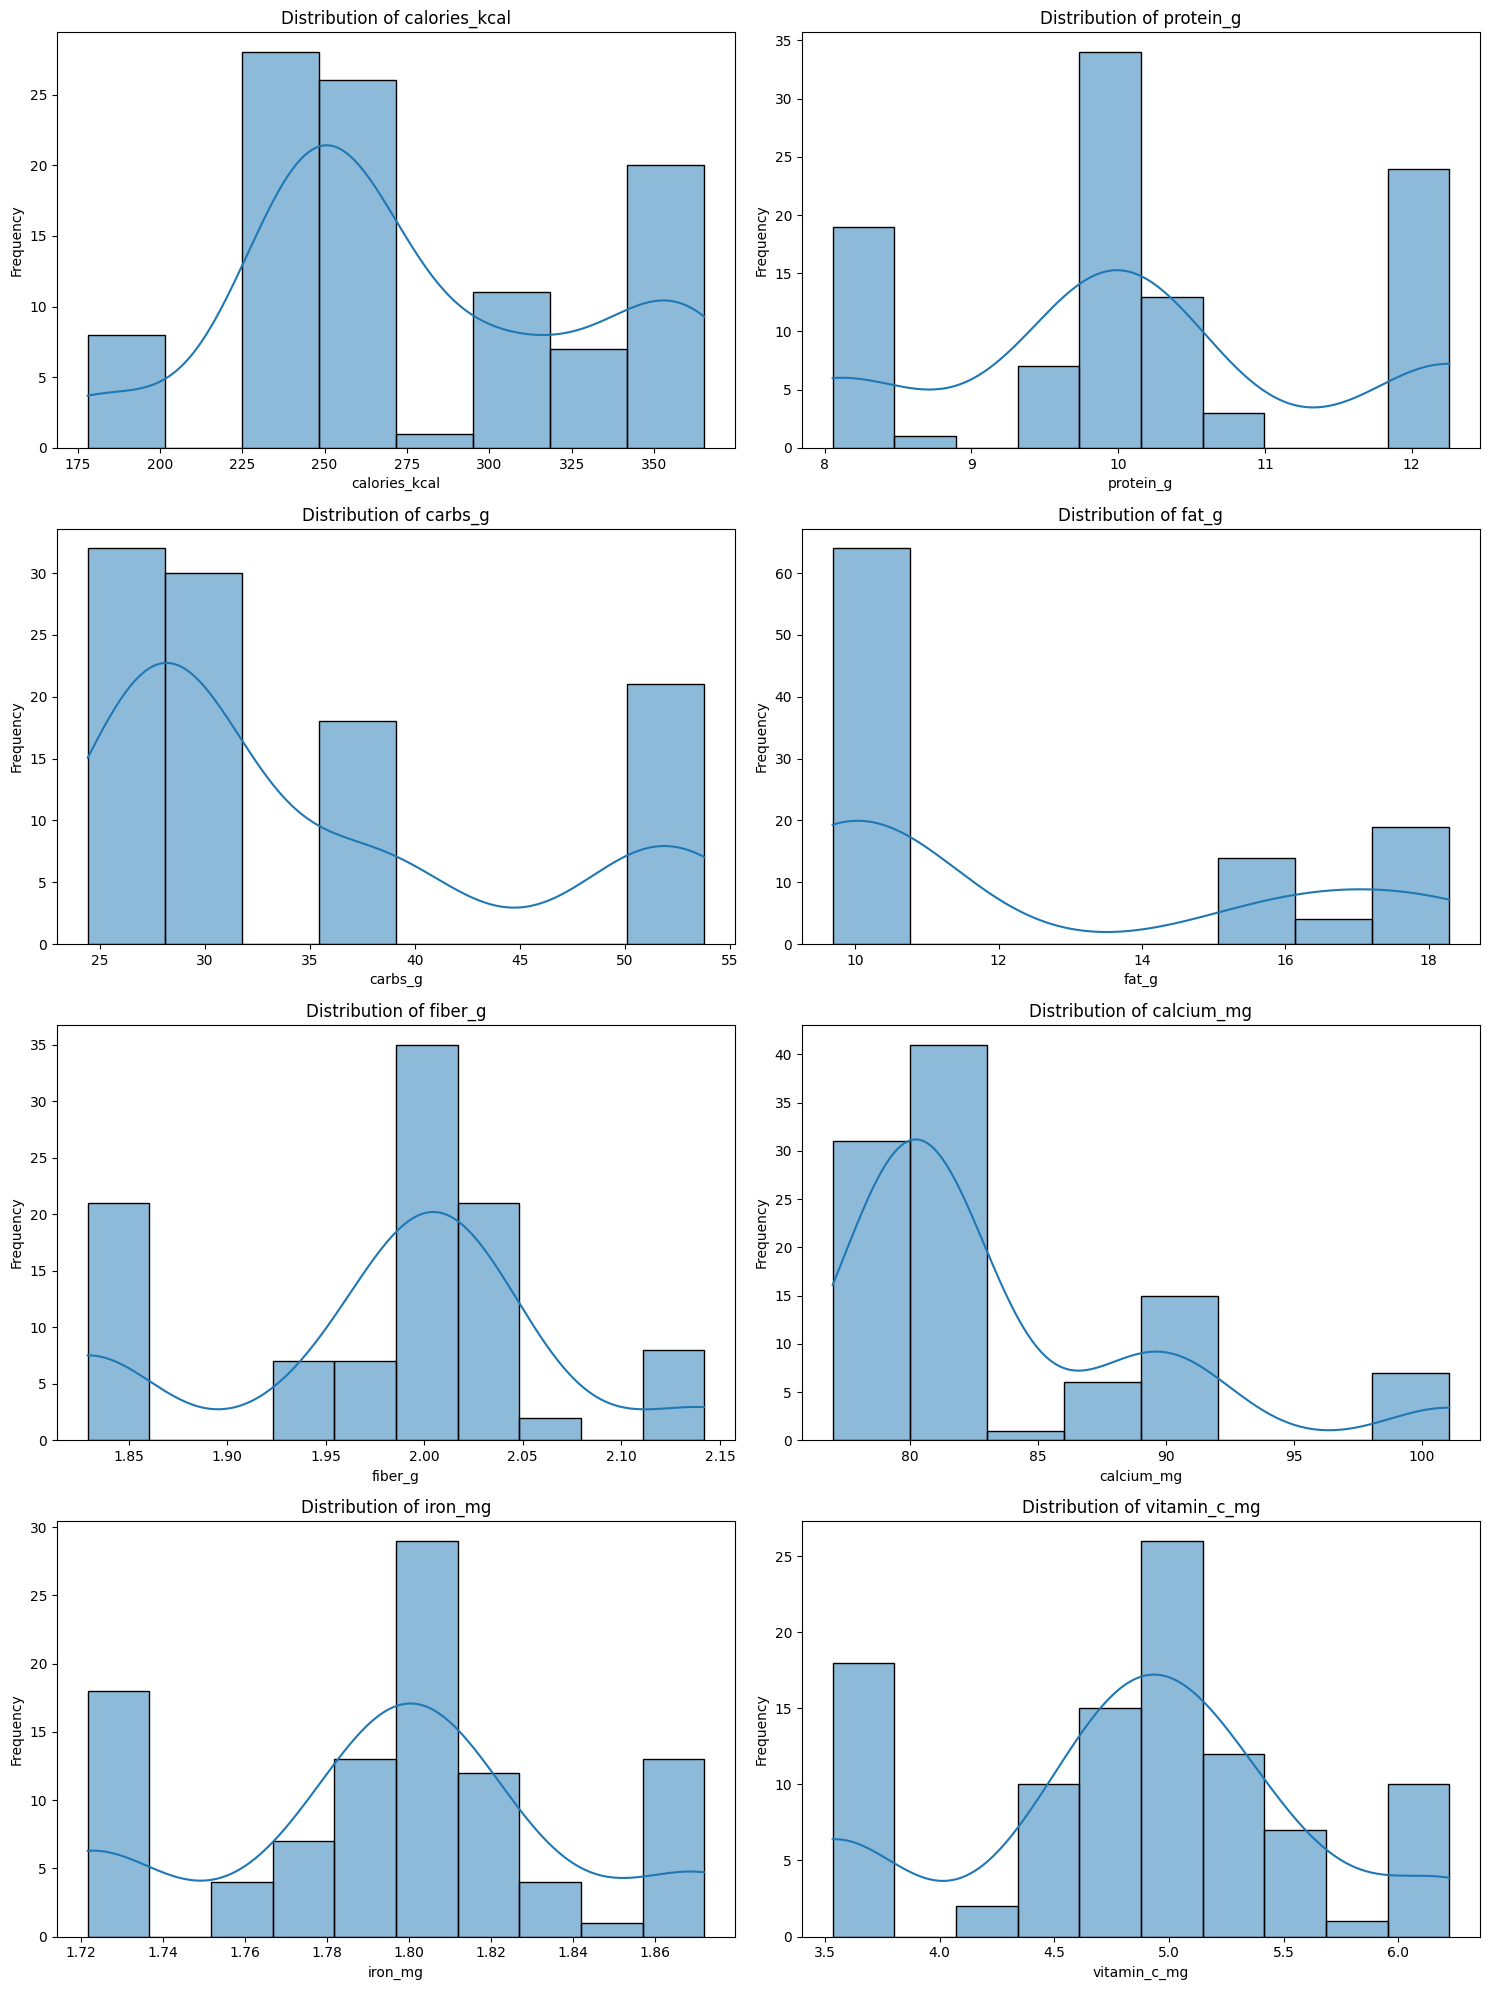

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_food = ['calories_kcal', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'calcium_mg', 'iron_mg', 'vitamin_c_mg']

# histograms
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols_food):
    plt.subplot(4, 2, i + 1)
    sns.histplot(food_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Insight:**

- **Calories**: Distribusi kalori terlihat **right-skewed** atau menceng ke kanan. Sebagian besar makanan memiliki jumlah kalori rendah hingga sedang, sementara hanya beberapa makanan yang memiliki nilai kalori sangat tinggi. Hal ini menunjukkan adanya kemungkinan outlier.

- **Protein**: Distribusi protein secara umum juga **right-skewed**, dengan sebagian besar makanan mengandung protein dalam jumlah rendah hingga sedang. Sebaran datanya cukup terlihat, tetapi hanya sedikit makanan yang memiliki kandungan protein sangat tinggi.

- **Carbohydrates**: Mirip dengan kalori, distribusi karbohidrat juga menunjukkan pola **right-skewed**. Artinya, banyak makanan memiliki kandungan karbohidrat yang rendah, tetapi terdapat beberapa makanan dengan jumlah karbohidrat yang lebih tinggi.

- **Fat**: Distribusi kandungan lemak juga **right-skewed**. Hal ini menunjukkan bahwa sebagian besar makanan memiliki kandungan lemak yang rendah, sedangkan hanya sebagian kecil makanan yang memiliki kadar lemak tinggi.

- **Fiber**: Distribusi serat terlihat sangat **right-skewed**, dengan sebagian besar makanan memiliki kandungan serat yang sangat rendah. Hanya sedikit makanan yang memiliki kandungan serat sedang hingga tinggi. Hal ini cukup wajar karena banyak makanan olahan tidak memiliki kandungan serat yang signifikan.

- **Calcium, Iron, dan Vitamin C**: Ketiga mikronutrien ini juga menunjukkan distribusi **right-skewed**, di mana sebagian besar makanan hanya menyediakan kandungan nutrisi dalam jumlah kecil, sementara beberapa makanan memiliki kandungan mikronutrien yang lebih tinggi.


#### Deteksi Outlier

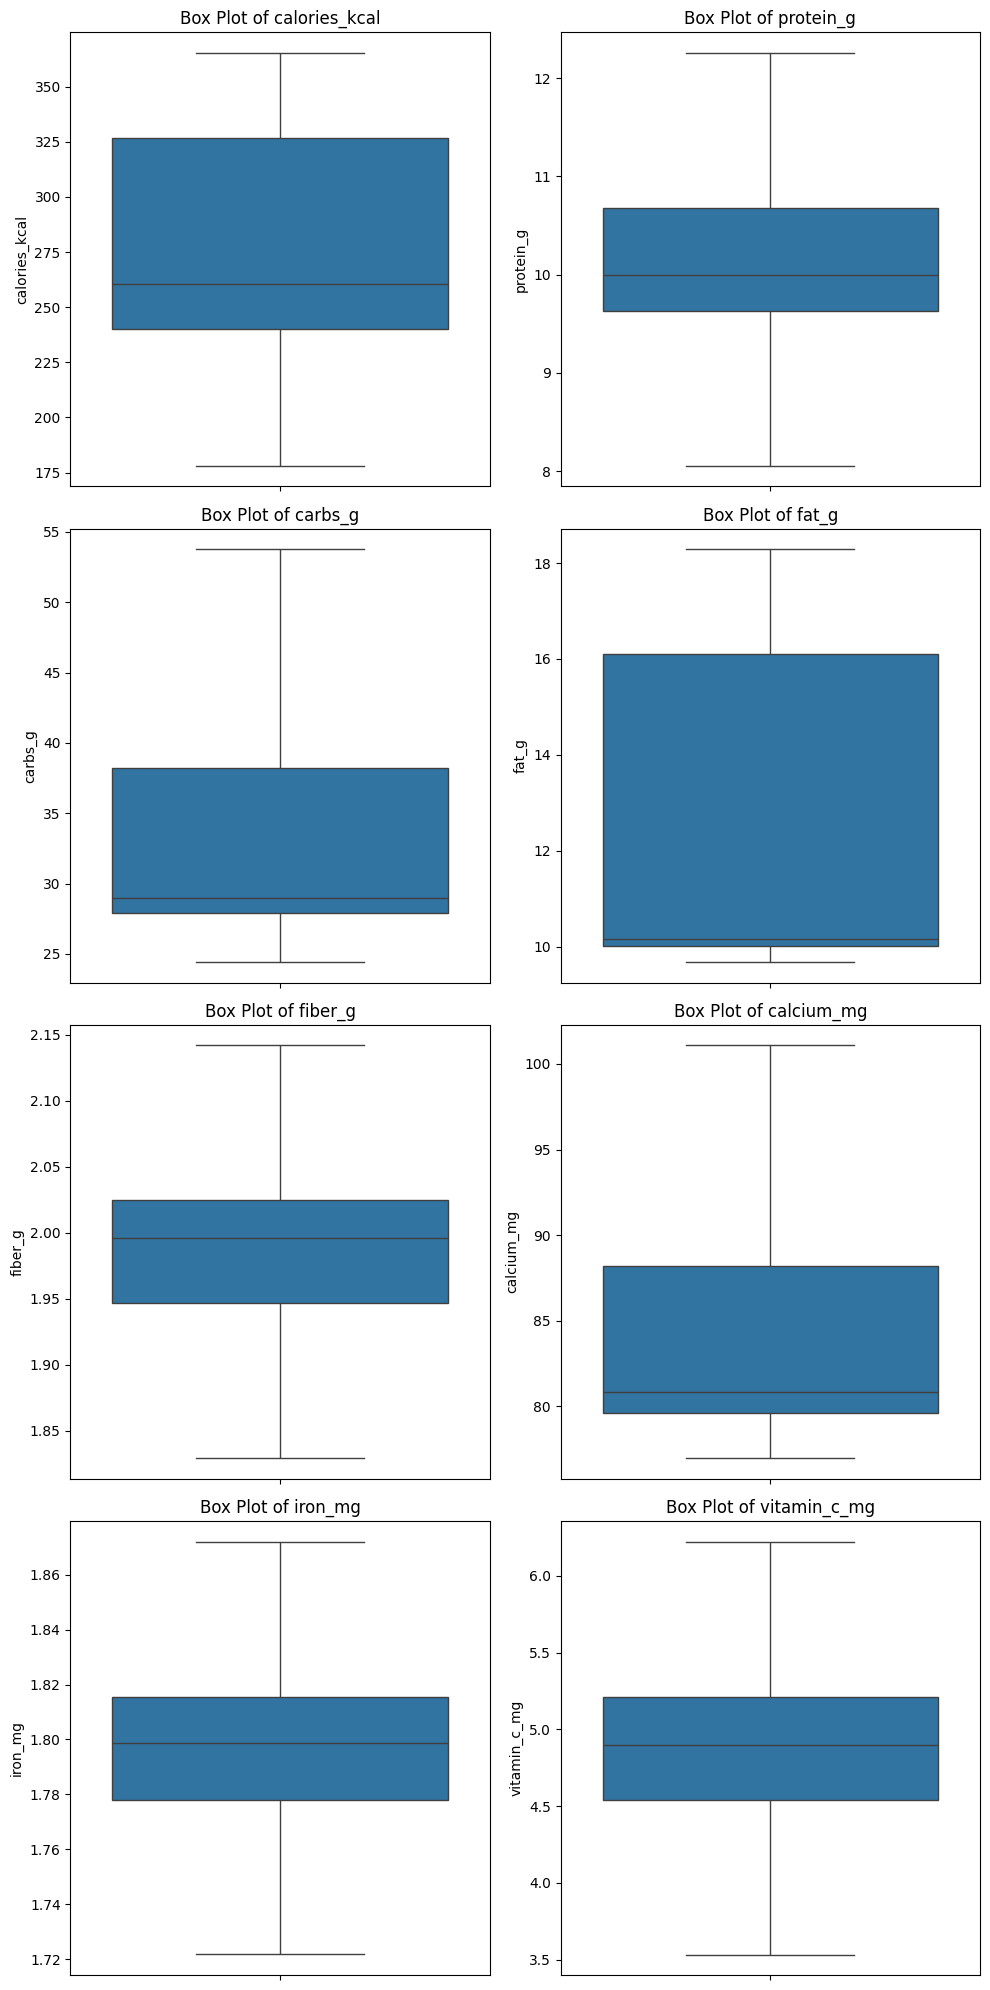

In [42]:
plt.figure(figsize=(10, 20))
for i, col in enumerate(numerical_cols_food):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(y=food_cleaned[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Insight:**

- **Calories**: Box plot pada calories menunjukkan adanya outlier yang cukup jelas pada nilai bagian atas. Artinya, terdapat beberapa makanan yang memiliki jumlah kalori jauh lebih tinggi dibandingkan sebagian besar data lainnya, meskipun sebelumnya sudah dilakukan proses capping outlier pada tahap cleaning. Distribusinya cenderung terkonsentrasi pada nilai yang lebih rendah.

- **Protein**: Sama seperti calories, protein juga menunjukkan beberapa outlier pada nilai bagian atas. Hal ini menunjukkan bahwa terdapat beberapa makanan yang memiliki kandungan protein sangat tinggi. Sebagian besar data terkonsentrasi pada kadar protein yang lebih rendah.

- **Carbohydrates**: Carbohydrates juga menunjukkan adanya outlier pada nilai bagian atas. Ini menunjukkan bahwa beberapa makanan memiliki kandungan karbohidrat yang jauh lebih tinggi dibandingkan makanan lainnya. Distribusinya bersifat right-skewed atau menceng ke kanan.

- **Fat**: Fat menunjukkan cukup banyak outlier pada nilai bagian atas. Artinya, terdapat beberapa makanan yang memiliki kandungan lemak jauh lebih tinggi dibandingkan mayoritas data. Distribusi ini juga bersifat right-skewed.

- **Fiber**: Box plot fiber menunjukkan distribusi yang sangat skewed dengan banyak outlier pada nilai bagian atas. Hal ini berarti sebagian besar makanan memiliki kandungan serat yang sangat rendah, sedangkan hanya sebagian kecil makanan yang memiliki kandungan serat jauh lebih tinggi. Nilai median fiber sangat rendah, dan bentuk box terlihat sangat rapat di bagian bawah.

- **Calcium, Iron, dan Vitamin C**: Untuk ketiga mikronutrien ini, box plot secara umum menunjukkan distribusi yang cenderung terkonsentrasi pada nilai rendah, dengan beberapa outlier tersebar pada nilai bagian atas. Hal ini menunjukkan bahwa sebagian besar makanan hanya mengandung mikronutrien dalam jumlah sedang atau kecil, sementara beberapa makanan merupakan sumber mikronutrien yang sangat baik. Sebagai contoh, Vitamin C memiliki outlier yang cukup menonjol, menunjukkan bahwa beberapa makanan sangat kaya akan kandungan Vitamin C.

Kesimpulannya adalah hal ini umum terjadi pada data nutrisi karena makanan memiliki nilai nutrisi yang berbeda-beda, ada yang sangat banyak dan ada yang sedikit.


####Kebutuhan Nutrisi Berdasarkan Usia dan Jenis Kelamin

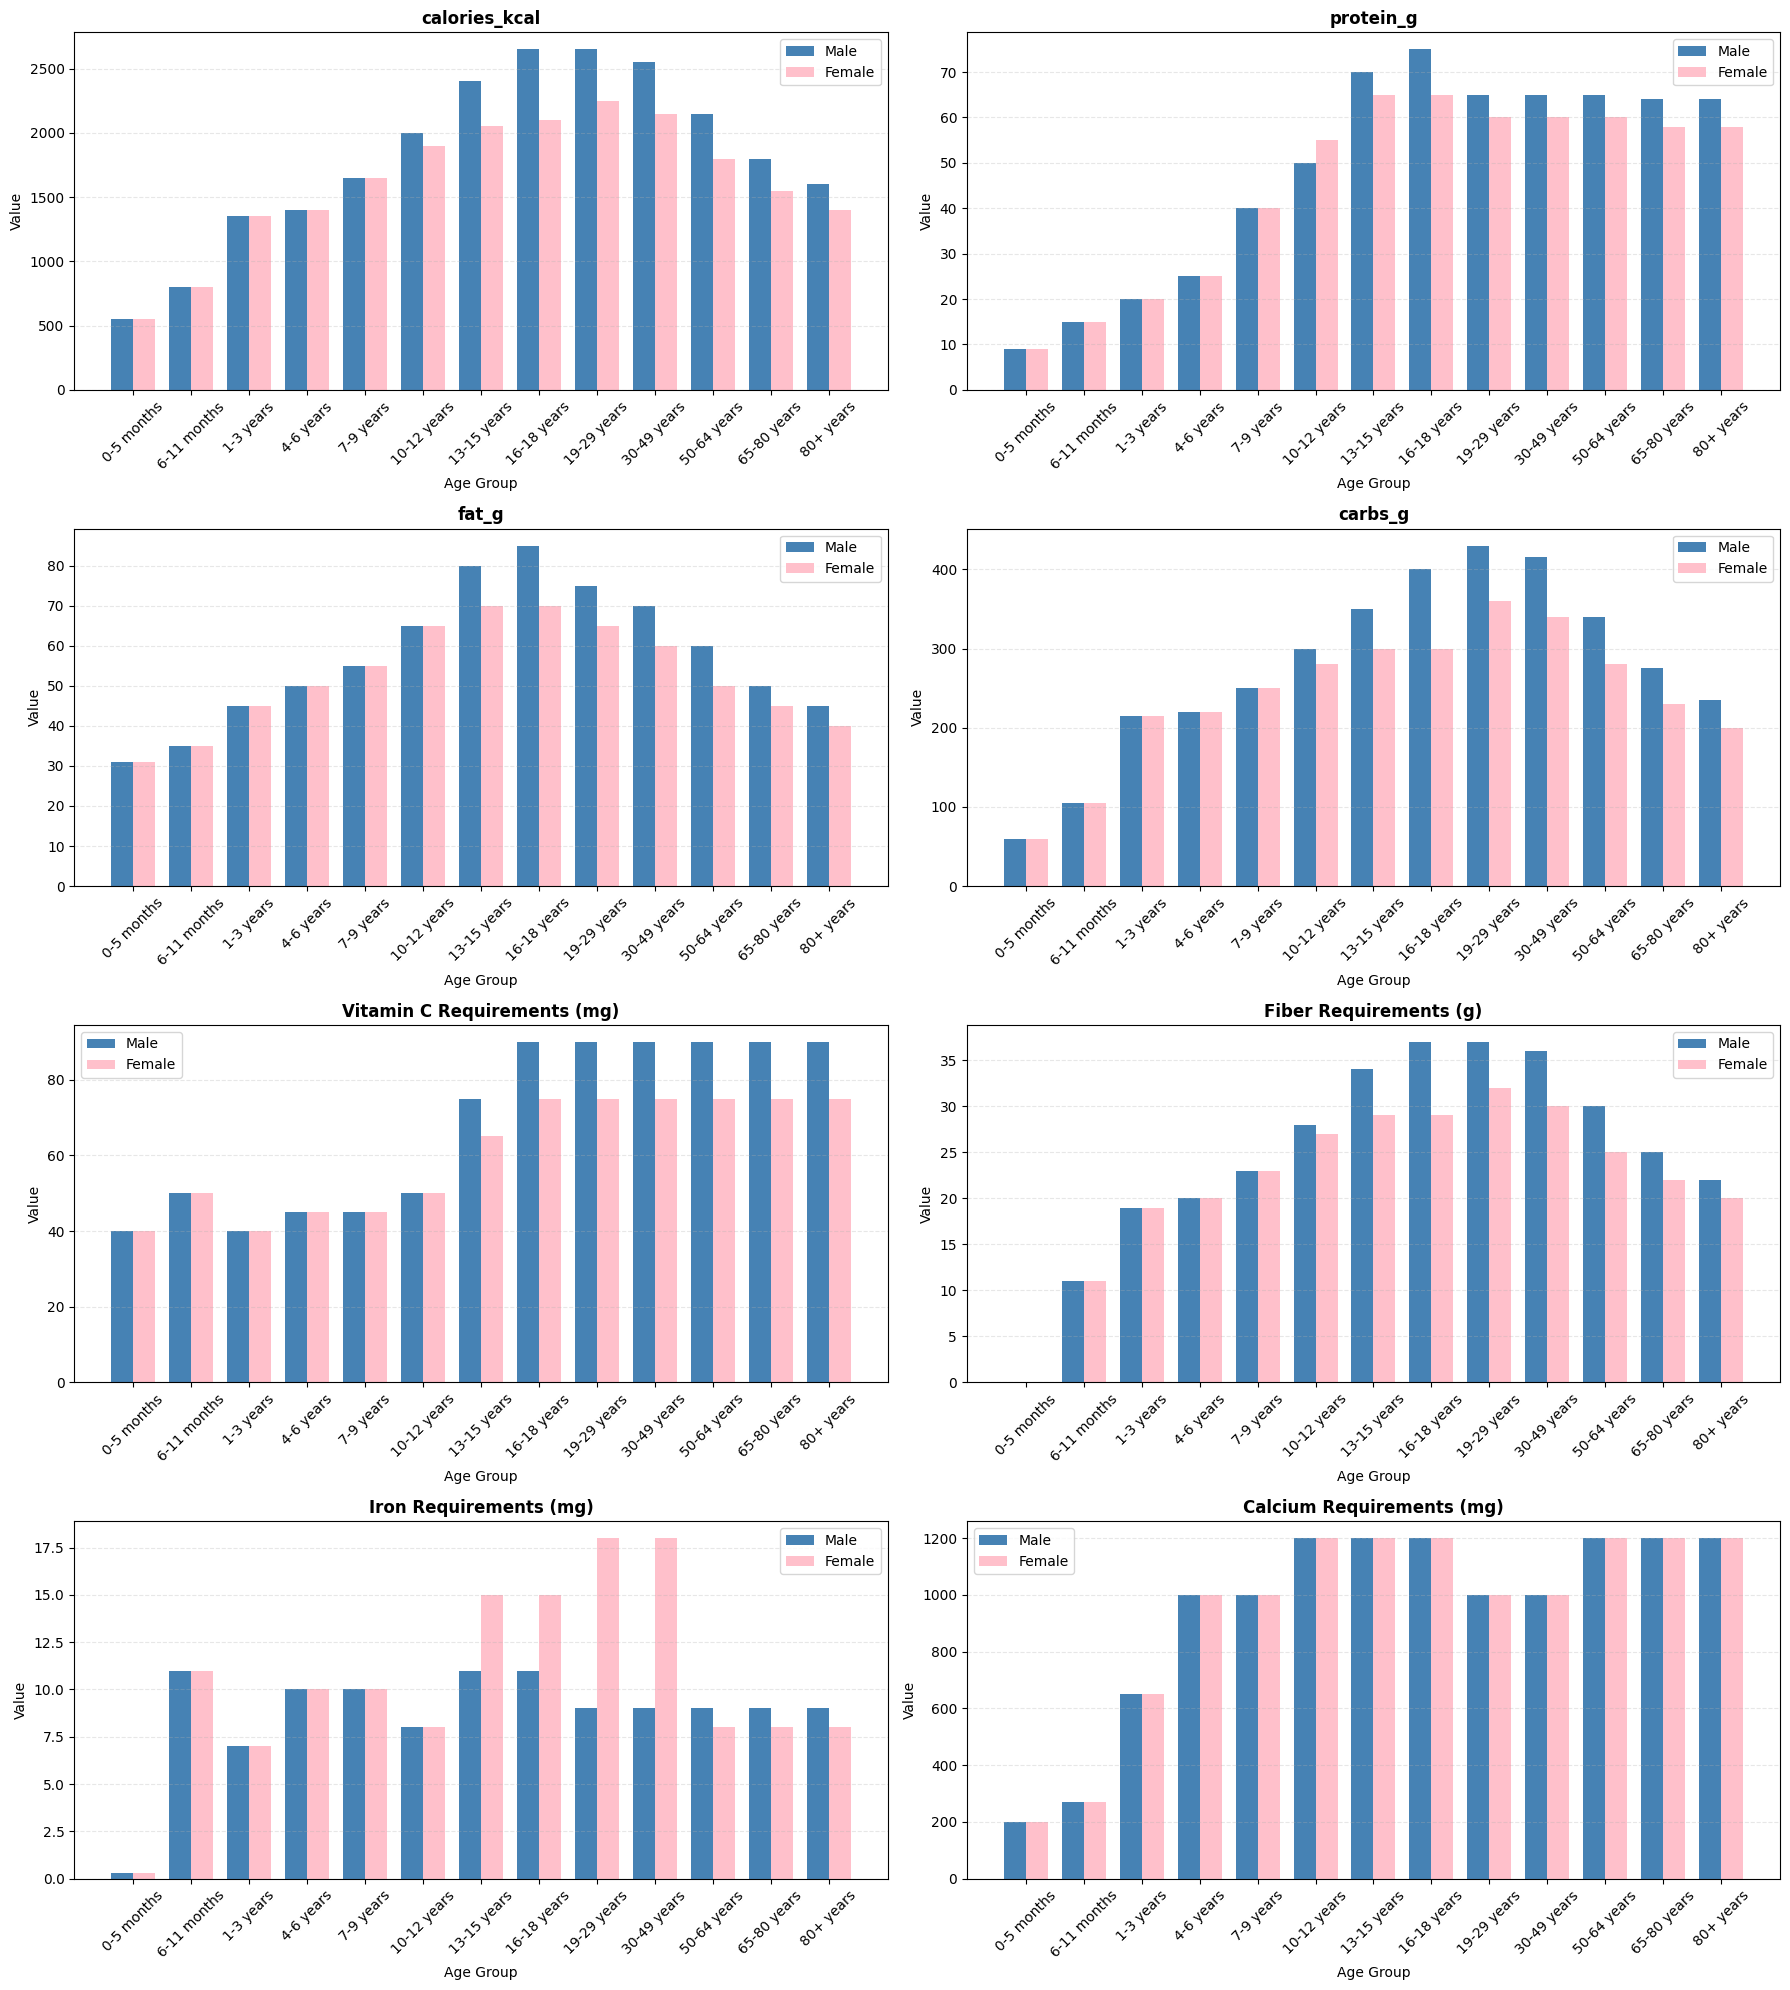

In [43]:
df_plot = akg_normal.copy()

# Data child
child_df = df_plot[df_plot["age_category"] == "infants_children"].copy()

# Duplikasi child -> male & female
child_male = child_df.copy()
child_male["gender"] = "Male"

child_female = child_df.copy()
child_female["gender"] = "Female"

# Data male & female asli
adult_df = df_plot[df_plot["age_category"].isin(["male", "female"])].copy()

adult_df["gender"] = adult_df["age_category"].map({
    "male": "Male",
    "female": "Female"
})

# Gabungkan semua
final_df = pd.concat(
    [child_male, child_female, adult_df],
    ignore_index=True
)

# Urutan age group
age_order = [
    "0-5 months",
    "6-11 months",
    "1-3 years",
    "4-6 years",
    "7-9 years",
    "10-12 years",
    "13-15 years",
    "16-18 years",
    "19-29 years",
    "30-49 years",
    "50-64 years",
    "65-80 years",
    "80+ years"
]

final_df["age_group"] = pd.Categorical(
    final_df["age_group"],
    categories=age_order,
    ordered=True
)

final_df = final_df.sort_values("age_group")

# DAFTAR NUTRISI

nutrient_cols = [
    "calories_kcal",
    "protein_g",
    "fat_g",
    "carbs_g",
    "vitamin_c_mg",
    "fiber_g",
    "iron_mg",
    "calcium_mg"
]

# SUBPLOTS (2 KOLOM)

n_cols = 2
n_rows = math.ceil(len(nutrient_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 5)
)

axes = axes.flatten()

title_mapping = {
  "calories": "Energy Requirements (kcal)",
  "protein": "Protein Requirements (g)",
  "fat": "Total Fat Requirements (g)",
  "carbs": "Carbohydrate Requirements (g)",
  "vitamin_c_mg": "Vitamin C Requirements (mg)",
  "fiber_g": "Fiber Requirements (g)",
  "iron_mg": "Iron Requirements (mg)",
  "calcium_mg": "Calcium Requirements (mg)"

}

# LOOP VISUALISASI
for i, nutrient in enumerate(nutrient_cols):

    # Skip kalau kolom tidak ada
    if nutrient not in final_df.columns:
        continue

    ax = axes[i]

    pivot_df = final_df.pivot_table(
        index="age_group",
        columns="gender",
        values=nutrient,
        observed=False
    ).fillna(0)

    x = np.arange(len(pivot_df.index))
    width = 0.38

    # Male
    ax.bar(
        x - width/2,
        pivot_df.get("Male", 0),
        width=width,
        color="steelblue",
        label="Male"
    )

    # Female
    ax.bar(
        x + width/2,
        pivot_df.get("Female", 0),
        width=width,
        color="pink",
        label="Female"
    )

    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=45)

    ax.set_title(
      title_mapping.get(nutrient, nutrient),
      fontsize=12,
      fontweight="bold"
    )

    ax.set_xlabel("Age Group")
    ax.set_ylabel("Value")

    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.legend()

# Hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:**
- Energy Requirements (kcal): Kebutuhan energi meningkat seiring pertumbuhan usia dan mencapai puncak pada usia remaja hingga dewasa muda. Setelah itu, kebutuhan energi cenderung menurun pada usia lanjut. Laki-laki umumnya memiliki kebutuhan energi lebih tinggi dibanding perempuan.
- Protein Requirements (g): Kebutuhan protein meningkat dari masa bayi hingga remaja, kemudian relatif stabil pada usia dewasa. Kebutuhan protein laki-laki sedikit lebih tinggi dibanding perempuan pada sebagian besar kelompok usia.
- Total Fat Requirements (g): Kebutuhan lemak meningkat mengikuti pertumbuhan usia hingga remaja, lalu mulai menurun pada usia dewasa dan lanjut usia. Pola kebutuhan laki-laki cenderung lebih tinggi dibanding perempuan.
- Carbohydrate Requirements (g): Kebutuhan karbohidrat meningkat signifikan pada masa pertumbuhan dan mencapai nilai tertinggi pada usia remaja hingga dewasa muda. Setelah itu, kebutuhan karbohidrat mengalami penurunan pada usia lanjut.
- Fiber Requirements (g): Kebutuhan serat umumnya meningkat seiring usia hingga dewasa, kemudian cenderung stabil atau sedikit menurun pada usia lanjut. Tidak ada perbedaan signifikan antara laki-laki dan perempuan.
- Calcium Requirements (mg): Kebutuhan kalsium penting sepanjang hidup untuk kesehatan tulang dan gigi. Kebutuhan cenderung tinggi pada masa pertumbuhan (anak-anak dan remaja) dan pada usia lanjut, terutama pada perempuan pasca-menopause.
- Iron Requirements (mg): Kebutuhan zat besi sangat bervariasi berdasarkan usia dan jenis kelamin. Perempuan usia produktif (reproduksi) memiliki kebutuhan zat besi yang lebih tinggi dibandingkan laki-laki karena kehilangan darah saat menstruasi. Kebutuhan ini juga tinggi pada masa pertumbuhan.
- Vitamin C Requirements (mg): Kebutuhan vitamin C relatif stabil dari masa anak-anak hingga dewasa, dengan sedikit peningkatan pada beberapa kelompok usia. Tidak ada perbedaan besar antara laki-laki dan perempuan. Vitamin C penting untuk sistem imun dan penyerapan zat besi.
- Kesimpulan: Secara umum, kebutuhan gizi meningkat selama masa pertumbuhan, mencapai puncak pada usia remaja atau dewasa muda, lalu menurun pada usia lanjut. Selain itu, kebutuhan nutrisi laki-laki cenderung lebih tinggi dibanding perempuan pada hampir seluruh kategori nutrisi.

####Kebutuhan Nutrisi Harian Berdasarkan Usia pada Kondisi Ibu Hamil

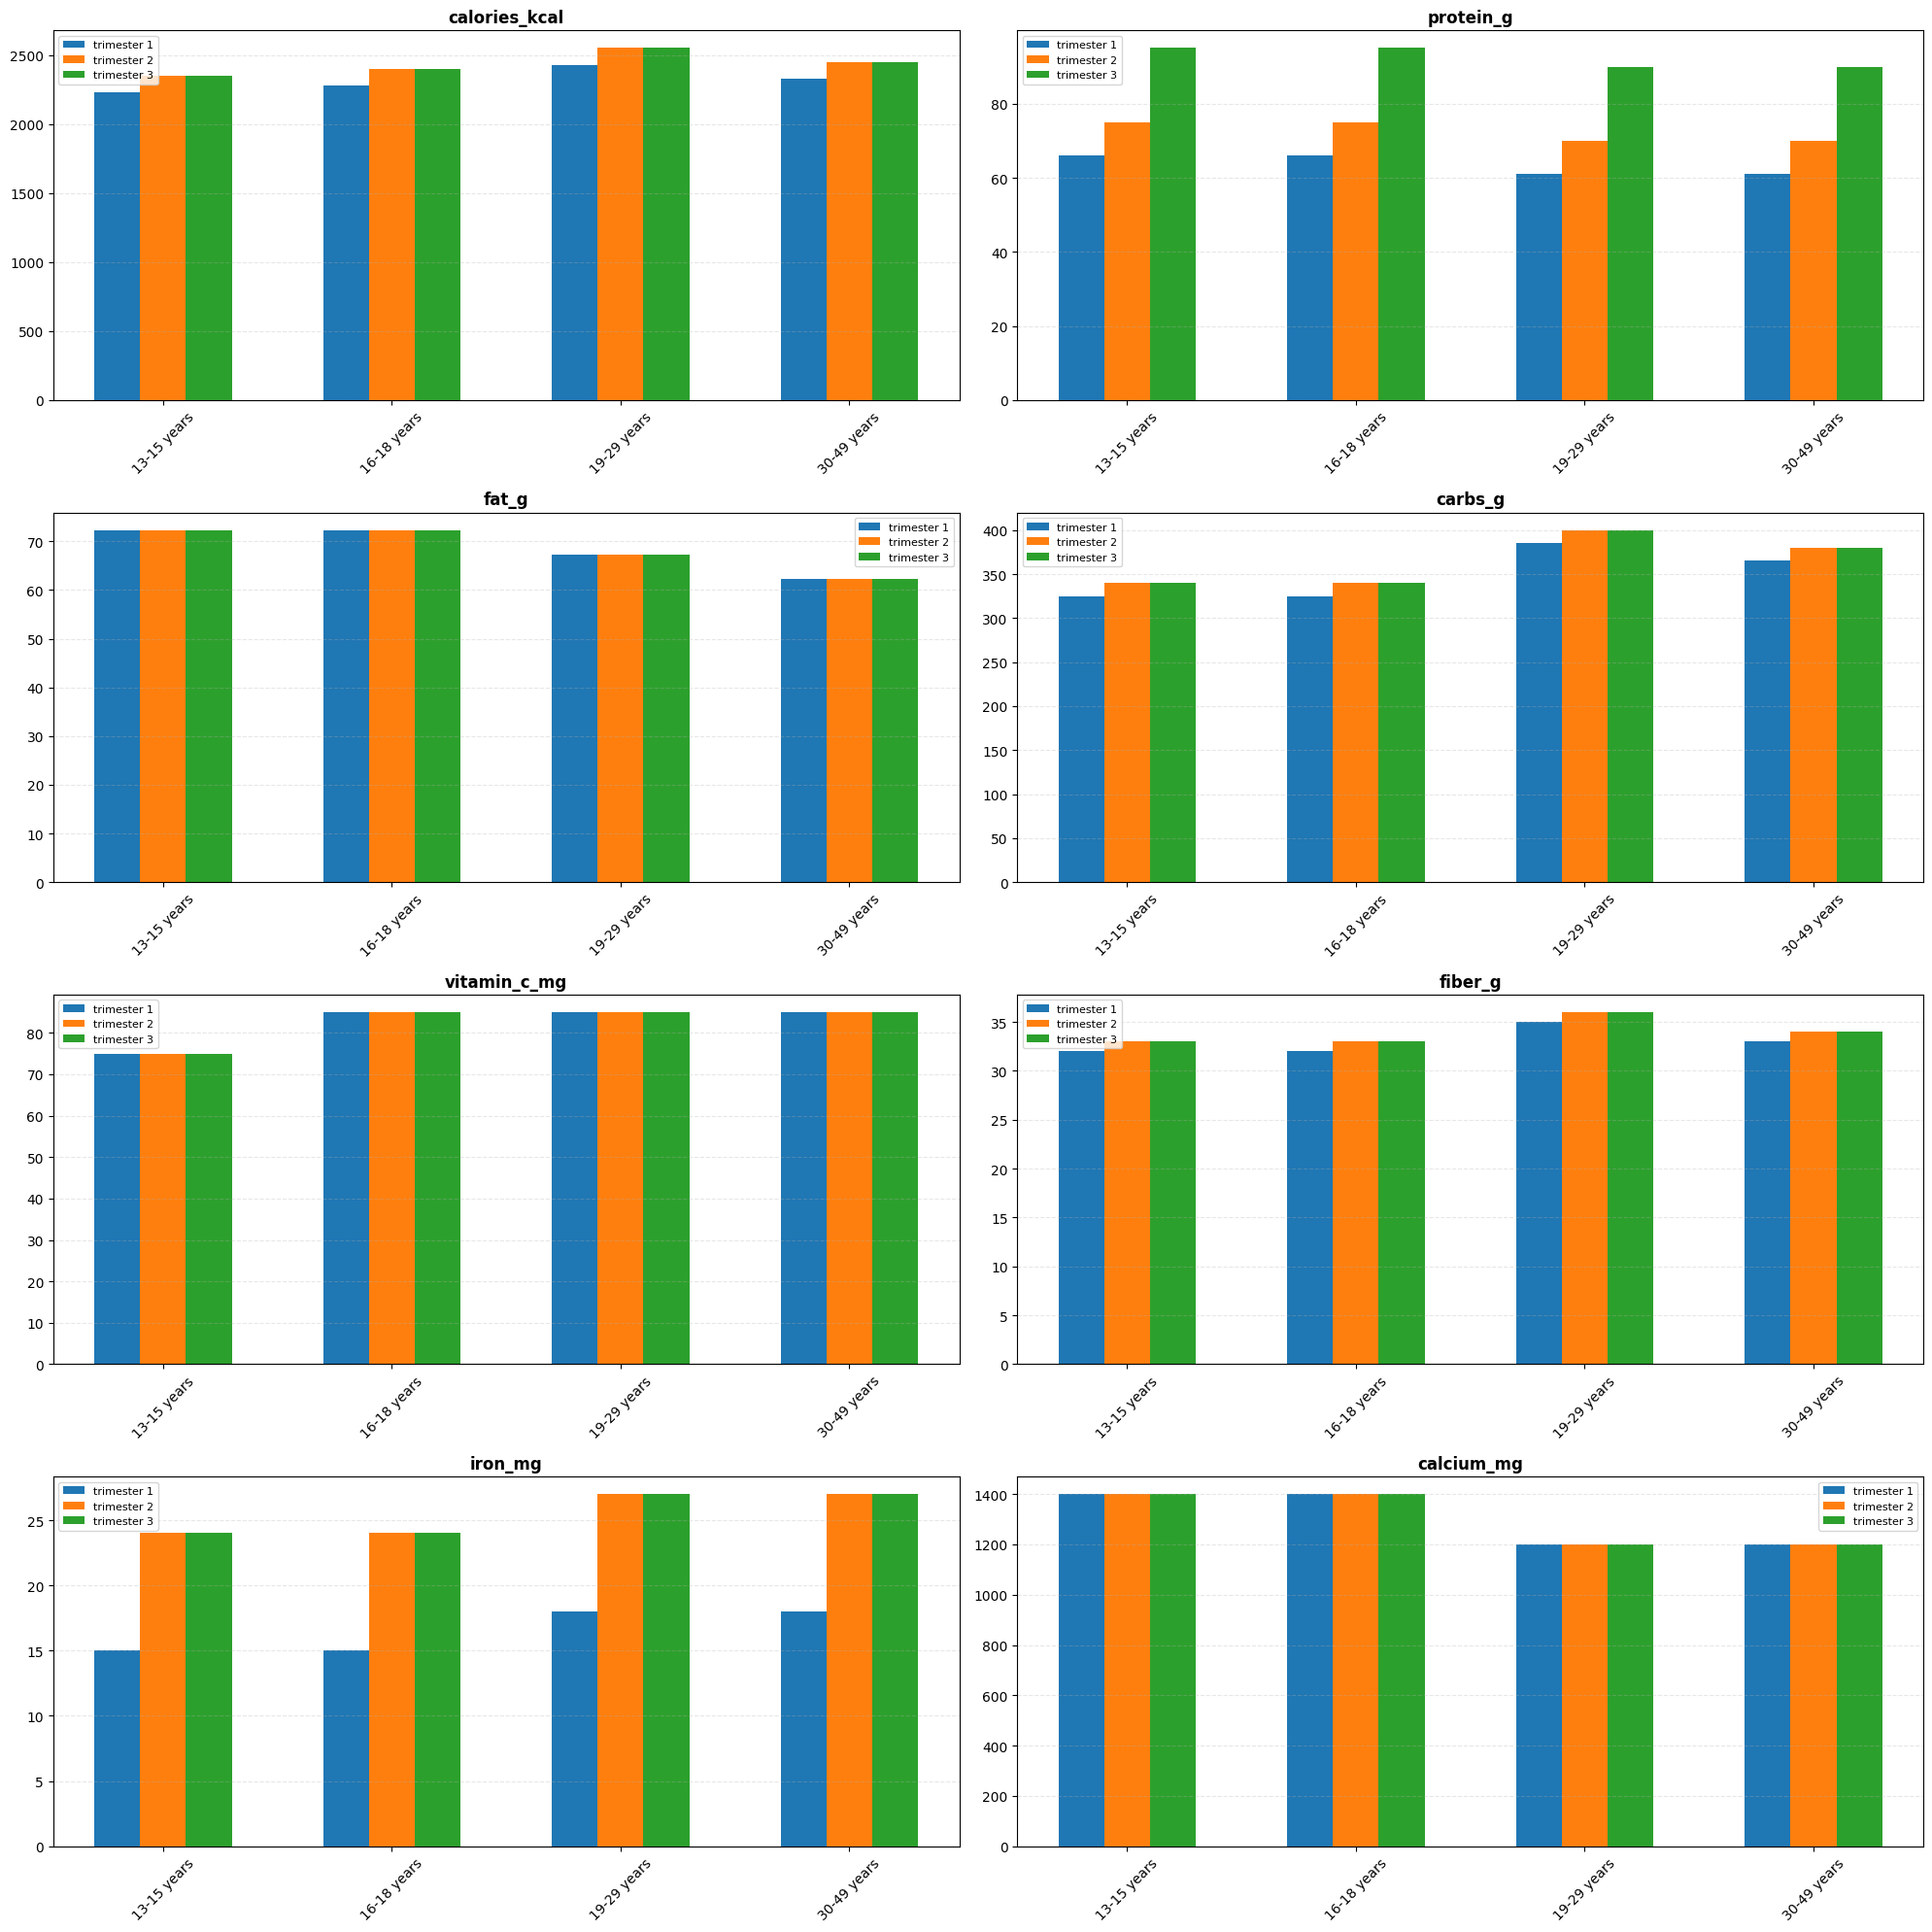

In [44]:
# DATA FEMALE DASAR
female_base = akg_normal[
    akg_normal["age_category"] == "female"
].copy()

female_base = female_base[
    female_base["min_age"].between(13, 49)
]

# LABEL TRIMESTER
pregnancy_labels = {
    "1st trimester": "Trimester 1",
    "2nd trimester": "Trimester 2",
    "3rd trimester": "Trimester 3"
}

# TITLE MAPPING
title_mapping = {
    "calories": "Energy Requirements (kcal)",
    "protein": "Protein Requirements (g)",
    "fat": "Total Fat Requirements (g)",
    "carbs": "Carbohydrate Requirements (g)"
}

# TAMBAHKAN KEBUTUHAN PREGNANT
pregnant_result = []

for _, preg_row in akg_pregnant.iterrows():

    matched_female = female_base[
        (female_base["min_age"] >= preg_row["min_age"]) &
        (female_base["max_age"] <= preg_row["max_age"])
    ]

    for _, female_row in matched_female.iterrows():

        new_row = female_row.copy()

        for nutrient in nutrient_cols:

            base_val = female_row.get(nutrient, 0)
            add_val = preg_row.get(nutrient, 0)

            base_val = 0 if pd.isna(base_val) else base_val
            add_val = 0 if pd.isna(add_val) else add_val

            new_row[nutrient] = base_val + add_val

        new_row["condition"] = pregnancy_labels.get(
            preg_row["age_group"],
            preg_row["age_group"]
        )

        pregnant_result.append(new_row)

pregnant_final = pd.DataFrame(pregnant_result)

# VISUALISASI
n_cols = 2
n_rows = math.ceil(len(nutrient_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 5)
)

axes = axes.flatten()

for i, nutrient in enumerate(nutrient_cols):
    ax = axes[i]
    pivot_df = pregnant_final.pivot_table(
        index="age_group",
        columns="condition",
        values=nutrient,
        observed=False
    )

    x = np.arange(len(pivot_df.index))
    conditions = list(pivot_df.columns)
    width = 0.2
    for j, condition in enumerate(conditions):
        offset = (j - (len(conditions) - 1) / 2) * width
        ax.bar(
            x + offset,
            pivot_df[condition],
            width=width,
            label=str(condition).strip()
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        pivot_df.index,
        rotation=45
    )
    ax.set_title(
        title_mapping.get(nutrient, nutrient),
        fontsize=12,
        fontweight="bold"
    )
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:**

- Kebutuhan energi pada perempuan hamil usia dewasa berada di kisaran 2300–2550 kkal per hari. Kebutuhan tertinggi terdapat pada kelompok usia 19–29 tahun, terutama pada trimester 3.
- Kebutuhan protein meningkat cukup signifikan dari trimester 1 ke trimester 3, yaitu dari sekitar 61–66 gram menjadi 90–95 gram per hari. Peningkatan ini diperlukan untuk mendukung pertumbuhan janin, plasenta, dan jaringan tubuh ibu.
- Kebutuhan lemak cenderung stabil pada setiap trimester, berkisar 62–67 gram per hari. Lemak berfungsi sebagai sumber energi cadangan dan mendukung perkembangan organ janin.
- Kebutuhan karbohidrat juga meningkat selama kehamilan. Pada usia dewasa, kebutuhan karbohidrat mencapai sekitar 380–400 gram per hari pada trimester 2 dan 3 sebagai sumber energi utama bagi ibu dan janin.
- Visualisasi secara keseluruhan menunjukkan bahwa kebutuhan gizi perempuan hamil meningkat seiring bertambahnya usia kehamilan, terutama pada trimester 2 dan trimester 3. Peningkatan paling terlihat pada kebutuhan energi dan protein.

####Kebutuhan Nutrisi Harian Berdasarkan Usia Pada Kondisi Ibu Menyusui

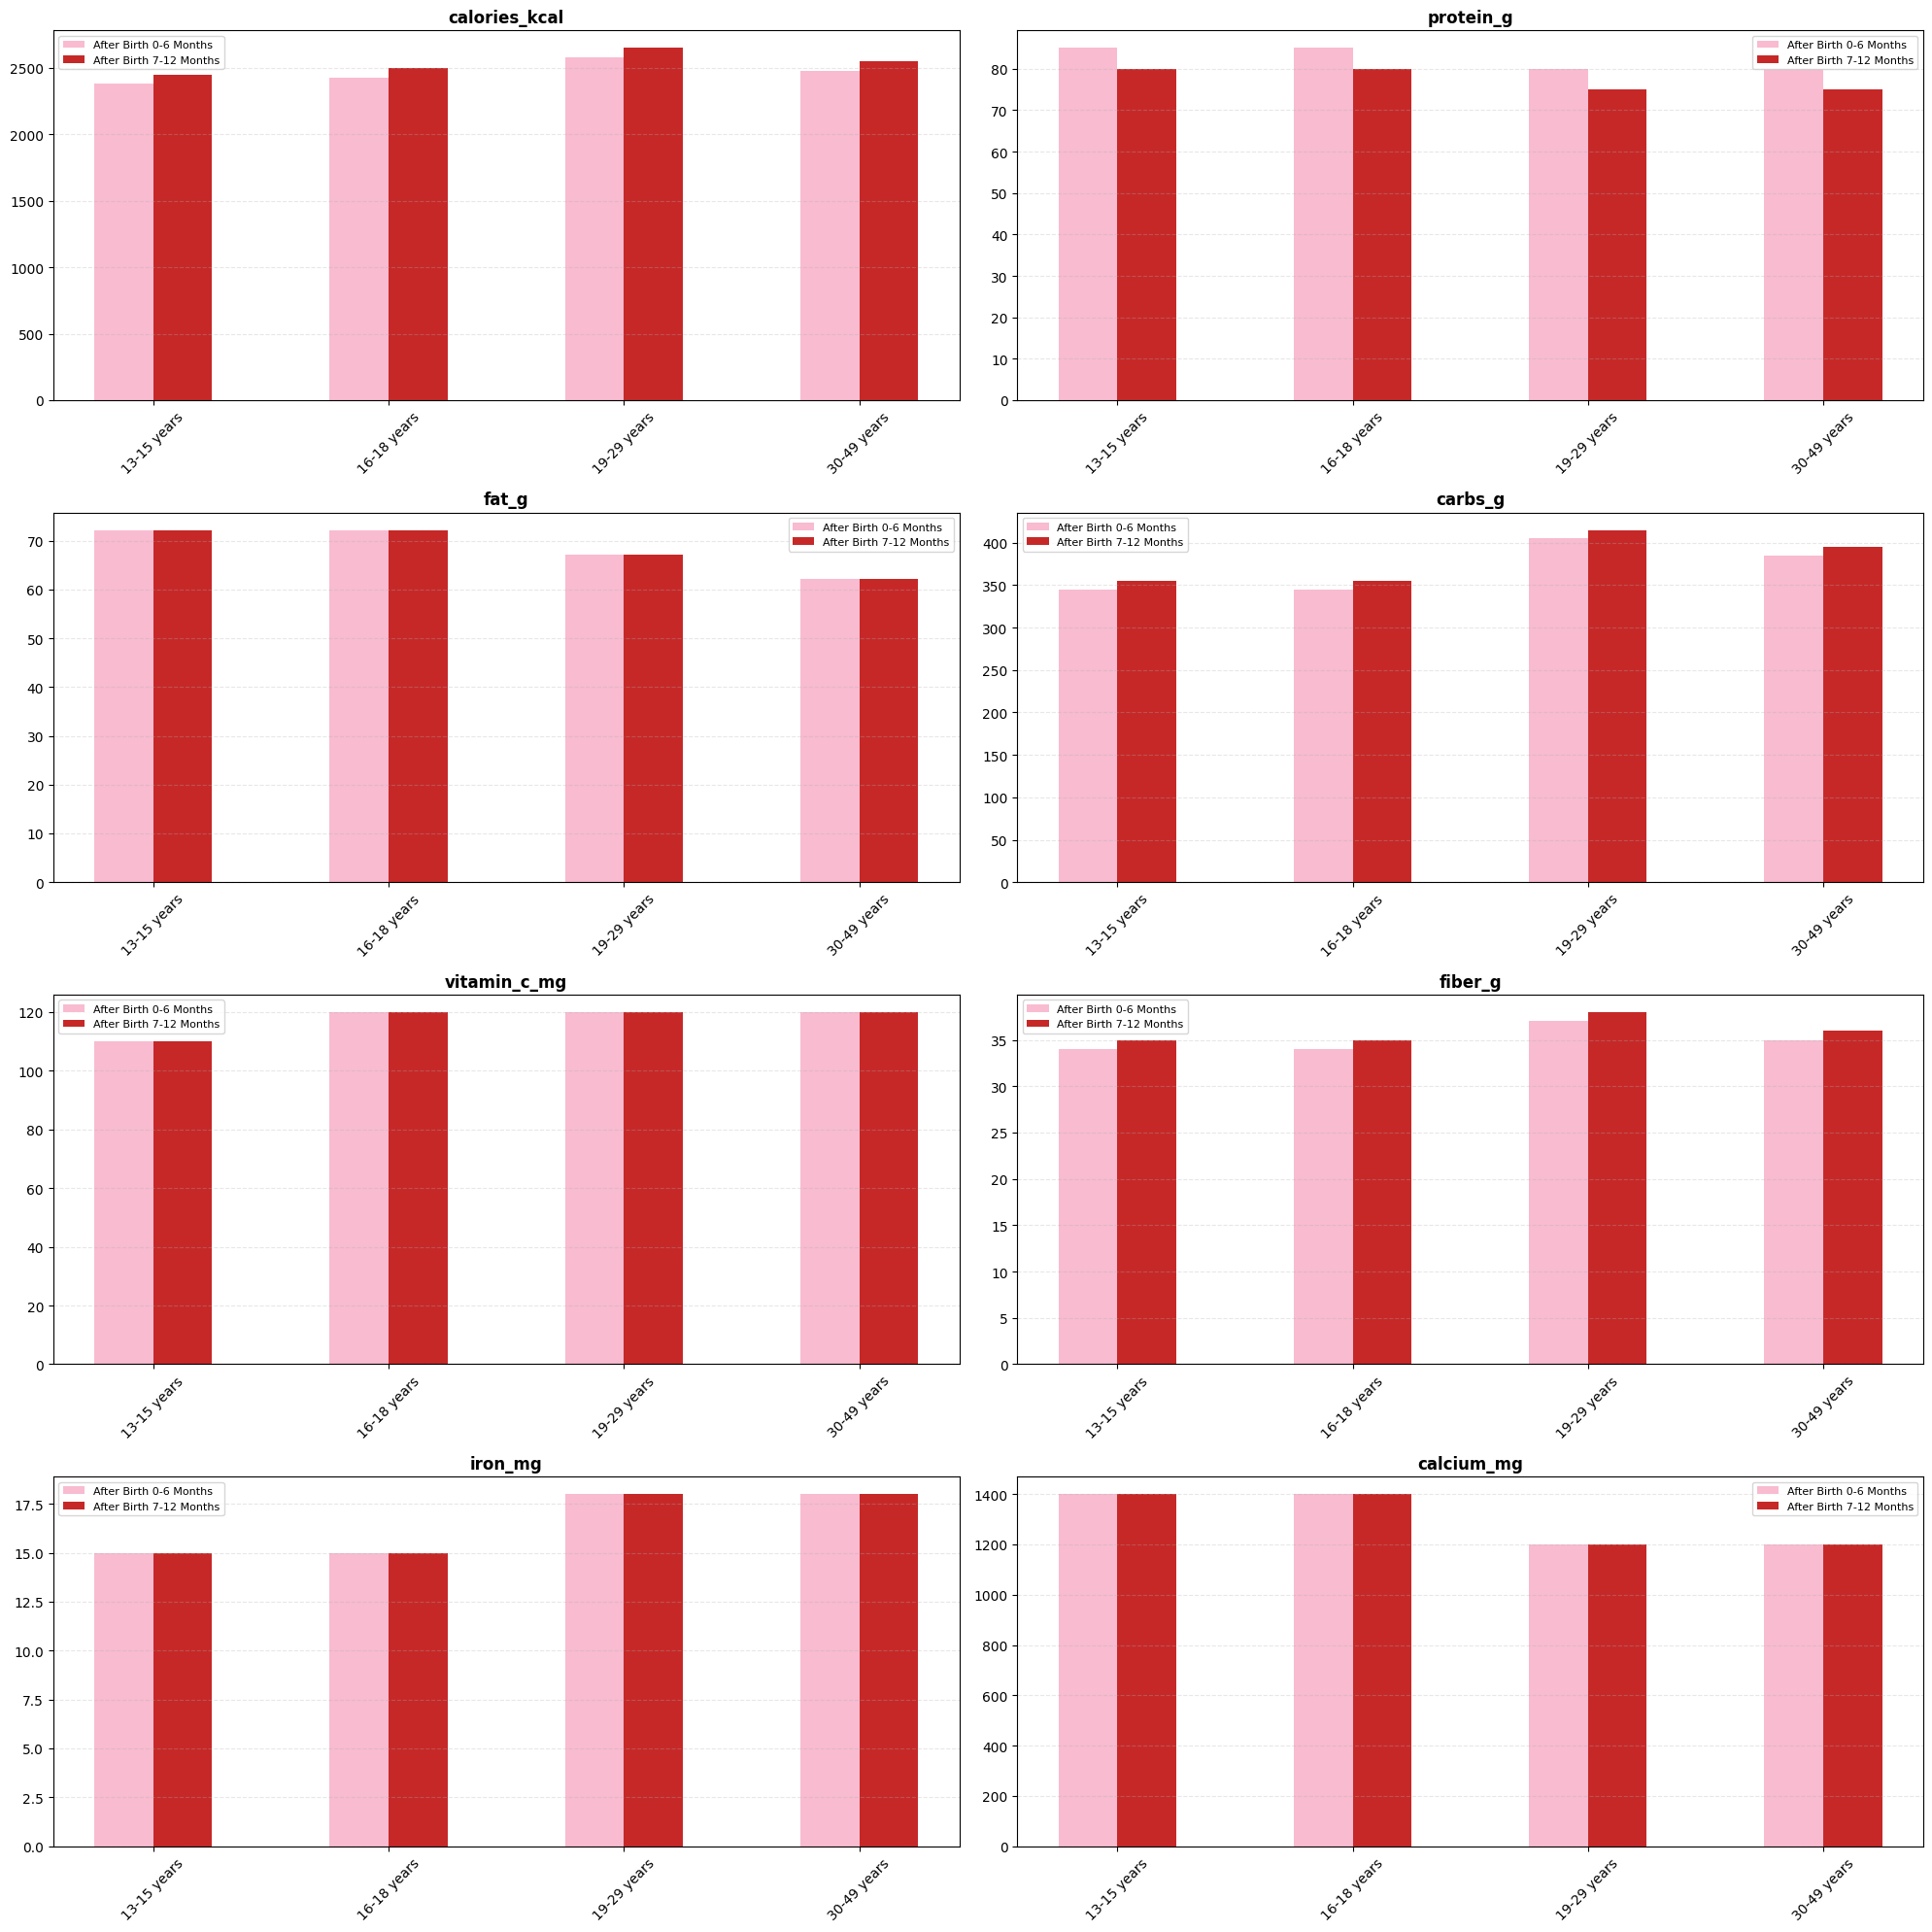

In [45]:
# LABEL BREASTFEEDING

breastfeeding_labels = {
    "first 6 months": "After Birth 0-6 Months",
    "second 6 months": "After Birth 7-12 Months"
}

# KEBUTUHAN BREASTFEEDING

breastfeeding_result = []

for _, bf_row in akg_breastfeeding.iterrows():

    matched_female = female_base[
        (female_base["min_age"] >= bf_row["min_age"]) &
        (female_base["max_age"] <= bf_row["max_age"])
    ]

    for _, female_row in matched_female.iterrows():

        new_row = female_row.copy()

        for nutrient in nutrient_cols:

            base_val = female_row.get(nutrient, 0)
            add_val = bf_row.get(nutrient, 0)

            base_val = 0 if pd.isna(base_val) else base_val
            add_val = 0 if pd.isna(add_val) else add_val

            new_row[nutrient] = base_val + add_val

        new_row["condition"] = breastfeeding_labels.get(
            bf_row["age_group"],
            bf_row["age_group"]
        )

        breastfeeding_result.append(new_row)

breastfeeding_final = pd.DataFrame(breastfeeding_result)

# WARNA

color_mapping = {
    "After Birth 0-6 Months": "#F8BBD0",
    "After Birth 7-12 Months": "#C62828"
}

# VISUALISASI

n_cols = 2
n_rows = math.ceil(len(nutrient_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 5)
)

axes = axes.flatten()

for i, nutrient in enumerate(nutrient_cols):

    ax = axes[i]

    pivot_df = breastfeeding_final.pivot_table(
        index="age_group",
        columns="condition",
        values=nutrient,
        observed=False
    )

    x = np.arange(len(pivot_df.index))
    conditions = list(pivot_df.columns)

    width = 0.25

    for j, condition in enumerate(conditions):

        offset = (j - (len(conditions)-1)/2) * width

        ax.bar(
            x + offset,
            pivot_df[condition],
            width=width,
            label=condition,
            color=color_mapping.get(condition)
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=45)

    ax.set_title(
        title_mapping.get(nutrient, nutrient),
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:**
- Kebutuhan energi ibu menyusui usia dewasa berada di kisaran 2400–2650 kkal per hari. Kelompok usia 19–29 tahun memiliki kebutuhan energi tertinggi, terutama pada periode 7–12 bulan setelah melahirkan.
- Kebutuhan protein berkisar antara 75–85 gram per hari. Pada 6 bulan pertama, kebutuhan protein cenderung lebih tinggi dibandingkan 6 bulan kedua karena produksi ASI masih sangat intensif pada masa awal menyusui.
- Kebutuhan lemak relatif stabil pada kedua periode menyusui, yaitu sekitar 62–72 gram per hari. Lemak berperan penting sebagai sumber energi dan mendukung kualitas ASI bagi bayi.
- Kebutuhan karbohidrat berada pada kisaran 350–410 gram per hari. Kelompok usia 19–29 tahun memiliki kebutuhan karbohidrat tertinggi untuk memenuhi kebutuhan energi selama proses menyusui.
- Grafik menunjukkan bahwa kebutuhan gizi ibu menyusui tetap tinggi baik pada 6 bulan pertama maupun 6 bulan kedua setelah melahirkan. Pada sebagian besar zat gizi, kebutuhan pada 6 bulan kedua sedikit lebih tinggi dibandingkan 6 bulan pertama.

### Kesimpulan


- Kebutuhan nutrisi harian berbeda berdasarkan usia dan jenis kelamin. Secara umum, kebutuhan energi dan zat gizi meningkat selama masa pertumbuhan, mencapai puncak pada usia remaja hingga dewasa muda, kemudian menurun pada usia lanjut. Laki-laki cenderung membutuhkan asupan lebih tinggi dibanding perempuan.
- Pada kondisi kehamilan, kebutuhan nutrisi meningkat seiring bertambahnya trimester, terutama pada energi dan protein. Peningkatan ini diperlukan untuk mendukung pertumbuhan janin dan perubahan fisiologis ibu selama kehamilan.
- Pada kondisi menyusui, kebutuhan energi dan zat gizi tetap tinggi baik pada 6 bulan pertama maupun 6 bulan kedua setelah melahirkan. Kebutuhan protein cenderung lebih tinggi pada awal masa menyusui karena produksi ASI yang intensif.
- Distribusi sebagian besar kandungan nutrisi menunjukkan pola right-skewed, di mana mayoritas makanan memiliki kandungan nutrisi rendah hingga sedang, sementara hanya sedikit makanan yang memiliki nilai nutrisi sangat tinggi.
- Distribusi kandungan nutrisi menunjukkan masih adanya outlier pada beberapa variabel, di mana sebagian besar makanan memiliki kandungan nutrisi rendah hingga sedang, sementara hanya sedikit makanan yang memiliki kandungan nutrisi sangat tinggi. Outlier pada data nutrisi merupakan hal yang wajar karena setiap makanan memiliki kandungan nutrisi yang berbeda-beda, baik dalam jumlah rendah maupun sangat tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
 Makanan apa saja yang paling efisien dalam memenuhi kebutuhan kalori dan protein harian (AKG) untuk individu usia 19–29 tahun, serta berapa porsi yang dibutuhkan untuk mencapainya?

In [46]:
akg_19_29_combined = akg_normal[(akg_normal['age_group'] == '19-29 years')].copy()
akg_calories_target = akg_19_29_combined['calories_kcal'].mean()
akg_protein_target = akg_19_29_combined['protein_g'].mean()

print(f"19-29 years: - Average Calories: {akg_calories_target:.2f} kcal, Average Protein: {akg_protein_target:.2f} g")

# hitung porsi untuk setiap makanan berdasarkan target AKG gabungan
food_cleaned['portions_calories'] = akg_calories_target / food_cleaned['calories_kcal']
food_cleaned['portions_protein'] = akg_protein_target / food_cleaned['protein_g']

# menangani kemungkinan pembagian dengan nol atau nilai tak hingga (infinite)
# mengganti nilai inf menjadi NaN, kemudian mengganti NaN dengan nilai besar untuk menunjukkan bahwa makanan tersebut membutuhkan porsi yang sangat besar agar kebutuhan gizi dapat terpenuhi.
# nilai besar (misalnya 1000) digunakan untuk menandakan tingkat efisiensi yang sangat rendah.
food_cleaned['portions_calories'] = food_cleaned['portions_calories'].replace([np.inf, -np.inf], np.nan)
food_cleaned['portions_protein'] = food_cleaned['portions_protein'].replace([np.inf, -np.inf], np.nan)
food_cleaned.fillna({'portions_calories': 1000, 'portions_protein': 1000}, inplace=True)

# overall_portions_combined adalah porsi terbesar yang dibutuhkan untuk memenuhi salah satu dari kalori atau protein, dikonversi ke gram
food_cleaned['overall_portions_combined'] = food_cleaned[['portions_calories', 'portions_protein']].max(axis=1) * 100

print(food_cleaned[['class_name', 'calories_kcal', 'protein_g',
                     'overall_portions_combined']].head())
# makanan teratas yang paling efisien (lower is better)
top_efficient_foods = food_cleaned.sort_values(by='overall_portions_combined').head(10)

print("\n Top 10 Most Efficient Foods for Individuals (19-29 years) (Combined AKG):")
print(top_efficient_foods[['class_name', 'calories_kcal', 'protein_g', 'overall_portions_combined']])

19-29 years: - Average Calories: 2450.00 kcal, Average Protein: 62.50 g
       class_name  calories_kcal  protein_g  overall_portions_combined
0       apple_pie     359.571373   8.054649                 775.949349
1  baby_back_ribs     302.040131  10.000229                 811.150489
2         baklava     360.895629   8.054649                 775.949349
3  beef_carpaccio     303.289101  12.255165                 807.810104
4    beef_tartare     298.474040  12.255165                 820.841906

 Top 10 Most Efficient Foods for Individuals (19-29 years) (Combined AKG):
          class_name  calories_kcal  protein_g  overall_portions_combined
22  chocolate_mousse     358.732449  10.000229                 682.960241
26        crab_cakes     357.761661  10.000229                 684.813457
58         ice_cream     356.422773  10.000229                 687.385933
16        cheesecake     362.043113   8.658545                 721.830295
36           falafel     334.385167   9.629843          

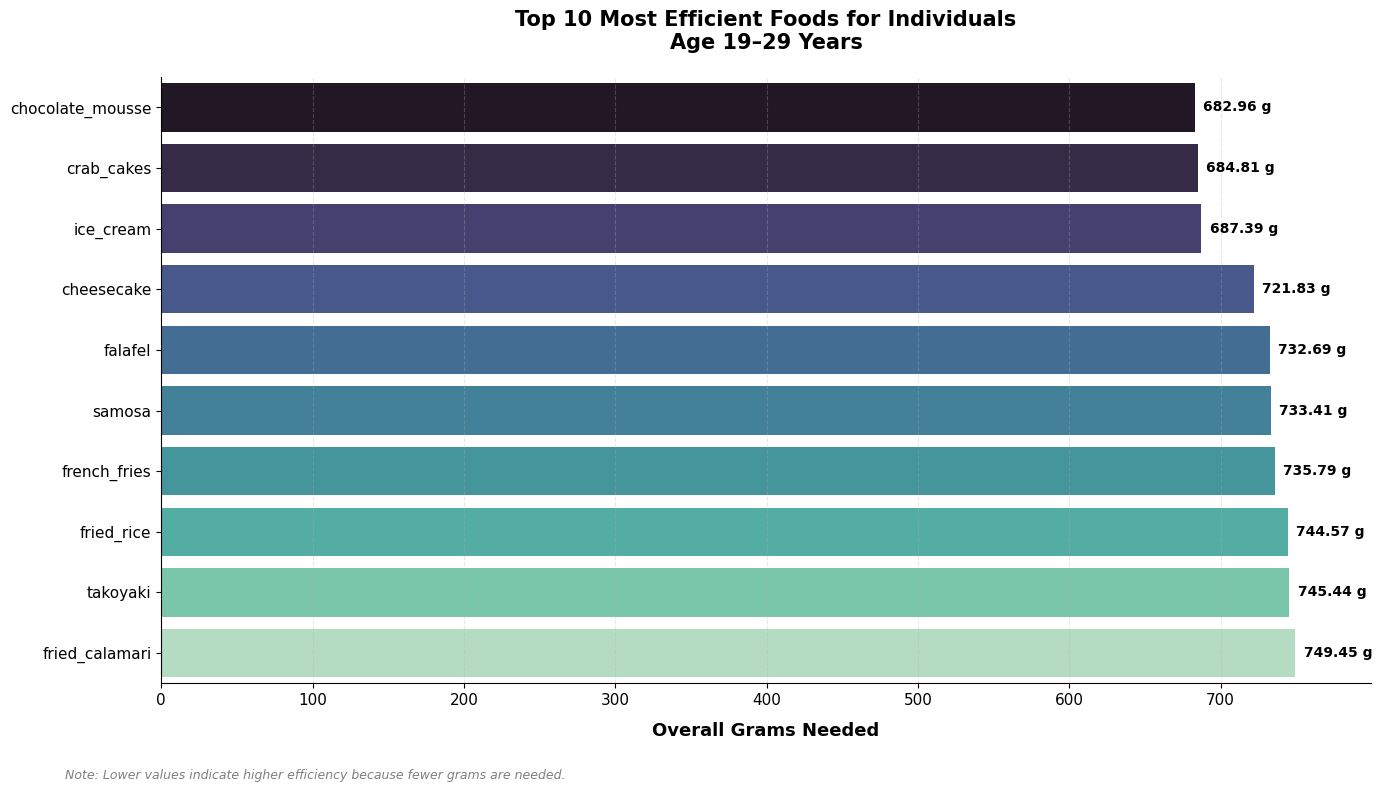

In [47]:
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=top_efficient_foods,
    x='overall_portions_combined',
    y='class_name',
    hue='class_name',
    palette='mako',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f g',
        padding=6,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top 10 Most Efficient Foods for Individuals\nAge 19–29 Years',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Overall Grams Needed',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel('')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.grid(
    axis='y',
    visible=False
)

sns.despine()

plt.xlim(
    0,
    top_efficient_foods['overall_portions_combined'].max() + 50
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.figtext(
    0.05,
    0.02,
    'Note: Lower values indicate higher efficiency because fewer grams are needed.',
    horizontalalignment='left',
    fontsize=9,
    color='gray',
    fontstyle='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Berdasarkan visualisasi barplot di atas, makanan yang paling efisien dalam memenuhi kebutuhan kalori dan protein harian individu usia 19–29 tahun didominasi oleh makanan tinggi energi seperti beignets (675,64 g), carrot cake (677,12 g), dan crab cakes (683,20 g). Selanjutnya terdapat ice cream (699,68 g) dan cheesecake (721,26 g). Beberapa makanan lain seperti bread pudding, baklava, cannoli, chocolate cake, dan creme brulee membutuhkan jumlah yang sama, yaitu sekitar 730,08 gram untuk memenuhi kebutuhan harian.

Secara umum, semakin kecil jumlah gram yang dibutuhkan, maka semakin efisien makanan tersebut dalam memenuhi kebutuhan AKG karena kandungan energi dan protein per gramnya lebih tinggi. Hal ini menunjukkan bahwa makanan dengan kepadatan kalori tinggi cenderung membutuhkan porsi lebih sedikit untuk mencapai target kebutuhan harian dibandingkan makanan dengan densitas energi rendah.

### Pertanyaan 2:
Seberapa banyak makanan dalam dataset yang memenuhi kebutuhan nutrisi berdasarkan standar AKG untuk perempuan usia 19-29 tahun pada kondisi masa menyusui (breastfeeding) 6 bulan pertama?

Total makanan: 101
Jumlah makanan yang memenuhi AKG: 0
Persentase makanan memenuhi AKG: 0.0 %


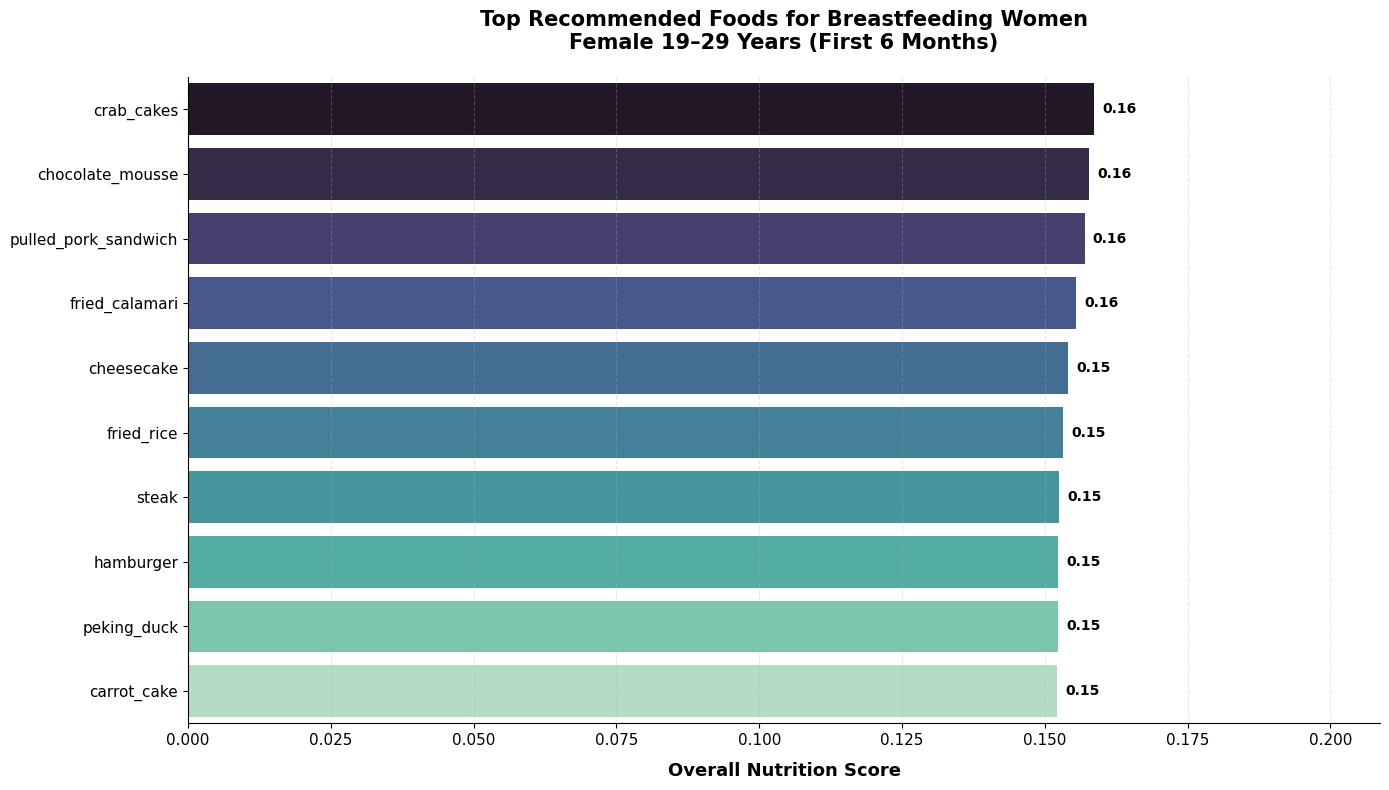

In [48]:
female_akg = akg_normal[
    (akg_normal['age_category'] == 'female') &
    (akg_normal['age_group'] == '19-29 years')
]

bf_akg = akg_breastfeeding[
    (akg_breastfeeding['age_category'] == 'breastfeeding') &
    (akg_breastfeeding['bf_month_max'] == 6.0)
]

TARGET_CALORIES = (
    female_akg['calories_kcal'].values[0] +
    bf_akg['calories_kcal'].values[0]
)

TARGET_PROTEIN = (
    female_akg['protein_g'].values[0] +
    bf_akg['protein_g'].values[0]
)

TARGET_FAT = (
    female_akg['fat_g'].values[0] +
    bf_akg['fat_g'].values[0]
)

TARGET_CARBS = (
    female_akg['carbs_g'].values[0] +
    bf_akg['carbs_g'].values[0]
)

df = food_cleaned.copy()

cols = ['calories_kcal', 'protein_g', 'fat_g', 'carbs_g']

df[cols] = df[cols].apply(
    pd.to_numeric,
    errors='coerce'
)

df = df.dropna(subset=cols)

df = df[
    (df['calories_kcal'] > 0) &
    (df['protein_g'] > 0)
]

df['calories_pct'] = (
    df['calories_kcal'] / TARGET_CALORIES
)

df['protein_pct'] = (
    df['protein_g'] / TARGET_PROTEIN
)

df['fat_pct'] = (
    df['fat_g'] / TARGET_FAT
)

df['carbs_pct'] = (
    df['carbs_g'] / TARGET_CARBS
)

df['overall_nutrition_score'] = (
    df['calories_pct'] +
    df['protein_pct'] +
    df['fat_pct'] +
    df['carbs_pct']
) / 4

df['meets_akg'] = (
    (df['calories_pct'] >= 1.0) &
    (df['protein_pct'] >= 1.0) &
    (df['fat_pct'] >= 1.0) &
    (df['carbs_pct'] >= 1.0)
)

total_foods = len(df)

foods_meet_akg = df['meets_akg'].sum()

percentage_meet_akg = (
    foods_meet_akg / total_foods
) * 100

print("Total makanan:", total_foods)
print("Jumlah makanan yang memenuhi AKG:", foods_meet_akg)
print(
    "Persentase makanan memenuhi AKG:",
    round(percentage_meet_akg, 2),
    "%"
)

#visualisasi
top_foods = df.sort_values(
    by='overall_nutrition_score',
    ascending=False
).head(10)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=top_foods,
    x='overall_nutrition_score',
    y='class_name',
    hue='class_name',
    palette='mako',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=6,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top Recommended Foods for Breastfeeding Women\nFemale 19–29 Years (First 6 Months)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Overall Nutrition Score',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel('')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.grid(
    axis='y',
    visible=False
)

sns.despine()

plt.xlim(
    0,
    top_foods['overall_nutrition_score'].max() + 0.05
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi di atas, tidak terdapat makanan dalam dataset yang mampu memenuhi seluruh kebutuhan nutrisi berdasarkan standar AKG perempuan usia 19–29 tahun pada masa menyusui 6 bulan pertama secara penuh dalam porsi 100 gram. Hal ini terlihat dari nilai overall nutrition score yang masih rendah, dengan skor tertinggi hanya mencapai 0,17.

Meskipun demikian, beberapa makanan memiliki skor nutrisi relatif lebih tinggi dibandingkan makanan lainnya, seperti beef carpaccio (0,17), beignets (0,16), crab cakes (0,16), dan ice cream (0,16). Selain itu, terdapat makanan lain seperti pulled pork sandwich, donuts, cup cakes, tiramisu, strawberry shortcake, dan fried rice dengan skor sekitar 0,15. Namun, skor tersebut masih jauh dari nilai ideal untuk memenuhi keseluruhan kebutuhan nutrisi harian ibu menyusui.

###Pertanyaan 3:

Apakah makanan yang tinggi kalori juga cenderung memiliki persentase pemenuhan AKG protein yang tinggi untuk individu usia 19–29 tahun?

In [49]:
# AKG protein usia 19-29 (gabungan)
akg_19_29 = akg_normal[
    akg_normal['age_group'] == '19-29 years'
].copy()

protein_target = akg_19_29['protein_g'].mean()

print(f"Protein AKG Target: {protein_target:.2f} g")

df = food_cleaned.copy()
# hitung persentase pemenuhan protein
df['protein_akg_percent'] = (
    df['protein_g'] / protein_target
) * 100

Protein AKG Target: 62.50 g


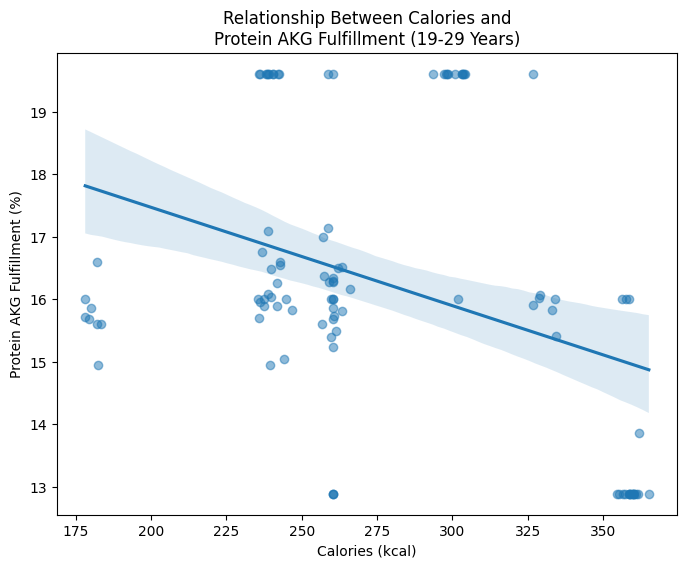

In [50]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='calories_kcal',
    y='protein_akg_percent',
    scatter_kws={'alpha':0.5}
)

plt.xlabel('Calories (kcal)')
plt.ylabel('Protein AKG Fulfillment (%)')

plt.title(
    'Relationship Between Calories and\n'
    'Protein AKG Fulfillment (19-29 Years)'
)

plt.show()

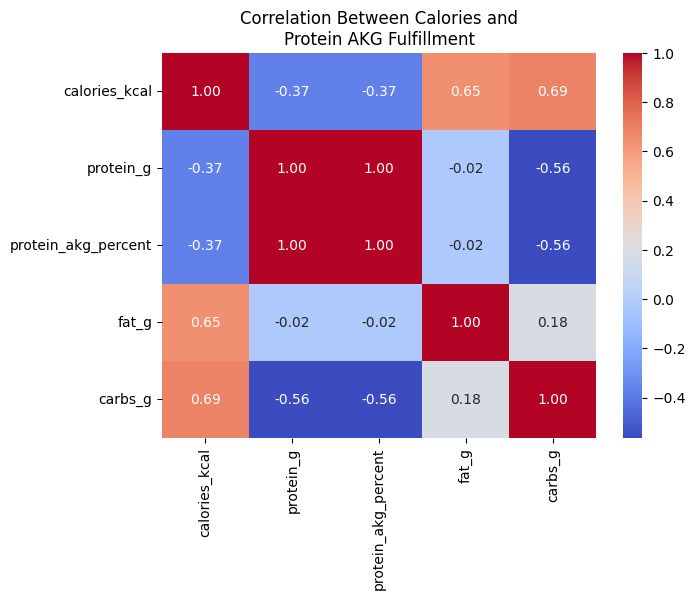

In [51]:
cols = [
    'calories_kcal',
    'protein_g',
    'protein_akg_percent',
    'fat_g',
    'carbs_g'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Between Calories and\n'
    'Protein AKG Fulfillment'
)

plt.show()

Distribusi data pada scatter plot memperlihatkan bahwa kenaikan jumlah kalori tidak selalu diikuti peningkatan pemenuhan AKG protein. Beberapa makanan dengan kalori cukup tinggi justru memiliki persentase protein yang relatif rendah, sedangkan makanan dengan kalori sedang masih mampu memberikan kontribusi protein yang lebih baik.

Kecenderungan tersebut diperkuat oleh nilai korelasi sebesar -0.51 antara kalori dan persentase AKG protein. Nilai negatif ini menandakan bahwa semakin tinggi kandungan kalori suatu makanan, kontribusi proteinnya justru cenderung menurun. Di sisi lain, kalori memiliki hubungan positif cukup kuat dengan karbohidrat (0.80), sehingga peningkatan energi pada dataset lebih banyak berasal dari kandungan karbohidrat dibanding protein.

###Pertanyaan 4:
Makanan apa saja yang memiliki skor tertinggi berdasarkan kandungan protein dan berapa persen pemenuhan kebutuhan protein pada wanita usia 19–29 tahun berdasarkan akg?

              class_name  protein_g  protein_akg_pct  portion_for_protein
4           beef_tartare  12.255165         0.204253             4.895895
3         beef_carpaccio  12.255165         0.204253             4.895895
19    chicken_quesadilla  12.255165         0.204253             4.895895
18         chicken_curry  12.255165         0.204253             4.895895
20         chicken_wings  12.255165         0.204253             4.895895
69               oysters  12.255165         0.204253             4.895895
74           peking_duck  12.255165         0.204253             4.895895
80  pulled_pork_sandwich  12.255165         0.204253             4.895895
77             pork_chop  12.255165         0.204253             4.895895
93                 steak  12.255165         0.204253             4.895895


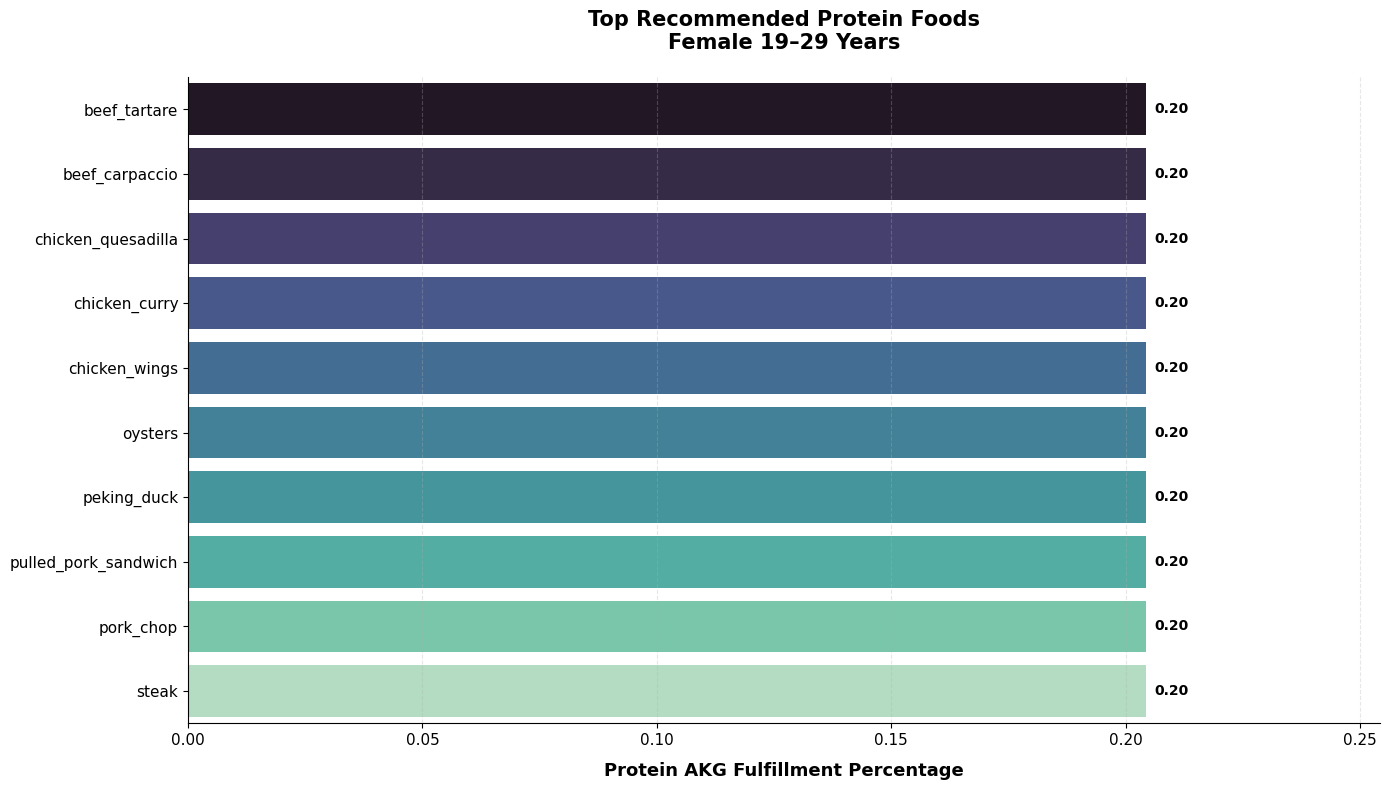

In [52]:
female_akg = akg_normal[
    (akg_normal['age_category'] == 'female') &
    (akg_normal['age_group'] == '19-29 years')
]

TARGET_PROTEIN = female_akg['protein_g'].values[0]

df = food_cleaned.copy()

df = df.groupby('class_name')[
    ['protein_g']
].mean().reset_index()

df['protein_akg_pct'] = (
    df['protein_g'] / TARGET_PROTEIN
)

df['portion_for_protein'] = (
    TARGET_PROTEIN / df['protein_g']
)

top_foods = df.sort_values(
    by='protein_akg_pct',
    ascending=False
).head(10)

print(
    top_foods[
        [
            'class_name',
            'protein_g',
            'protein_akg_pct',
            'portion_for_protein'
        ]
    ]
)
# VISUALIZATION

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=top_foods,
    x='protein_akg_pct',
    y='class_name',
    hue='class_name',
    palette='mako',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=6,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top Recommended Protein Foods\nFemale 19–29 Years',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Protein AKG Fulfillment Percentage',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel('')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.grid(
    axis='y',
    visible=False
)

sns.despine()

plt.xlim(
    0,
    top_foods['protein_akg_pct'].max() + 0.05
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Daftar makanan dengan skor protein tertinggi pada wanita usia 19–29 tahun didominasi oleh sumber protein hewani seperti baby back ribs, beef tartare, chicken wings, chicken quesadilla, bibimbap, oysters, peking duck, pulled pork sandwich, pork chop, hingga steak. Seluruh makanan pada peringkat teratas menunjukkan nilai pemenuhan AKG protein yang hampir sama, yaitu sekitar 19,23% dari kebutuhan protein harian. Hal ini menunjukkan bahwa makanan berbasis hewani cenderung memberikan kandungan protein lebih padat dibanding makanan lain dalam dataset.

###Pertanyaan 5:

Nutrisi apa yang paling sulit dipenuhi berdasarkan standar AKG perempuan usia 19–29 tahun jika hanya mengonsumsi satu jenis makanan?


In [53]:
# AKG female 19-29
akg_female_19_29 = akg_normal[
    (akg_normal['age_group'] == '19-29 years') &
    (akg_normal['age_category'] == 'female')
].copy()

# Make sure to work on a fresh copy of food_cleaned for this question
df = food_cleaned.copy()

# ambil target AKG
targets = {
    'calories_kcal': akg_female_19_29['calories_kcal'].mean(),
    'protein_g': akg_female_19_29['protein_g'].mean(),
    'fat_g': akg_female_19_29['fat_g'].mean(),
    'carbs_g': akg_female_19_29['carbs_g'].mean(),
    'fiber_g': akg_female_19_29['fiber_g'].mean(),
    'calcium_mg': akg_female_19_29['calcium_mg'].mean(),
    'iron_mg': akg_female_19_29['iron_mg'].mean(),
    'vitamin_c_mg': akg_female_19_29['vitamin_c_mg'].mean()
}

# hitung rata-rata persentase pemenuhan

average_fulfillment = {}

for nutrient, target in targets.items():

    percent = (
        df[nutrient] / target
    ) * 100

    average_fulfillment[nutrient] = percent.mean()

# ubah ke dataframe
difficulty_df = pd.DataFrame({
    'nutrient': average_fulfillment.keys(),
    'average_percent_fulfillment': average_fulfillment.values()
})

# urutkan dari yang paling sulit dipenuhi
difficulty_df = difficulty_df.sort_values(
    by='average_percent_fulfillment'
)

print(difficulty_df)

        nutrient  average_percent_fulfillment
4        fiber_g                     6.176674
7   vitamin_c_mg                     6.443174
5     calcium_mg                     8.363171
3        carbs_g                     9.652809
6        iron_mg                     9.973482
0  calories_kcal                    12.334163
1      protein_g                    16.927757
2          fat_g                    19.373345


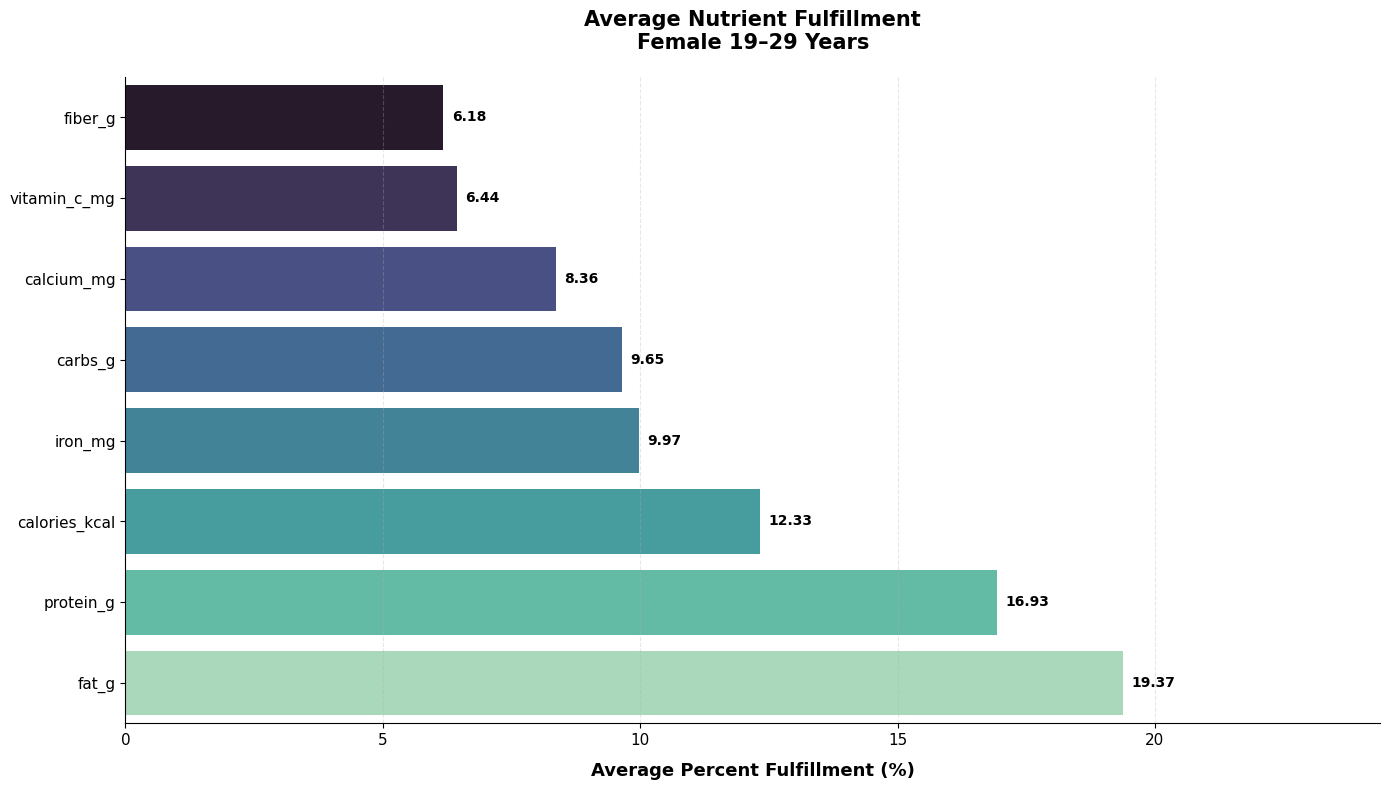

In [54]:
# urutkan dari paling sulit dipenuhi (kecil -> besar)
difficulty_df = difficulty_df.sort_values(
    by='average_percent_fulfillment',
    ascending=True
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=difficulty_df,
    x='average_percent_fulfillment',
    y='nutrient',
    hue='nutrient',
    palette='mako',
    legend=False
)

# label pada bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=6,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Average Nutrient Fulfillment\nFemale 19–29 Years',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Average Percent Fulfillment (%)',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel('')

# grid style
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.grid(
    axis='y',
    visible=False
)

sns.despine()

# batas sumbu x
plt.xlim(
    0,
    difficulty_df['average_percent_fulfillment'].max() + 5
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Rata-rata pemenuhan nutrisi pada perempuan usia 19–29 tahun menunjukkan perbedaan yang cukup besar antar zat gizi. Lemak (fat_g) menjadi nutrisi dengan tingkat pemenuhan tertinggi sebesar 19,81%, diikuti protein (16,77%) dan kalori (12,37%). Sebaliknya, serat (fiber_g) memiliki rata-rata pemenuhan paling rendah yaitu hanya 6,19%, disusul vitamin C (6,34%) dan kalsium (8,40%). Nilai tersebut menunjukkan bahwa beberapa nutrisi tertentu jauh lebih sulit dipenuhi apabila hanya mengandalkan satu jenis makanan dalam porsi 100 gram.

**Insight:**

**Pertanyaan 1:** Tingginya efisiensi pada makanan seperti beignets, bread pudding, dan cheesecake dipengaruhi oleh tingginya kandungan kalori dan kombinasi makronutrien dalam setiap porsinya, sehingga kebutuhan harian dapat tercapai dengan jumlah gram yang lebih sedikit. Namun, efisiensi berdasarkan total gram tidak selalu menunjukkan kualitas gizi yang lebih baik, karena beberapa makanan tersebut juga memiliki kandungan gula dan lemak yang cukup tinggi. Selain itu, perbedaan jumlah gram antar makanan pada visualisasi terlihat relatif kecil, yang menunjukkan bahwa sebagian besar makanan dalam daftar memiliki densitas energi yang hampir serupa dalam memenuhi kebutuhan kalori dan protein harian.

**Pertanyaan 2:** Tidak adanya makanan yang mampu memenuhi seluruh kebutuhan AKG ibu menyusui dalam porsi 100 gram menunjukkan bahwa kebutuhan nutrisi pada masa menyusui cenderung lebih tinggi dan kompleks dibanding kondisi normal. Pada periode ini, tubuh memerlukan tambahan energi, protein, vitamin, dan mineral untuk mendukung produksi ASI serta pemulihan tubuh ibu. Selain itu, penilaian dilakukan berdasarkan kandungan nutrisi per 100 gram makanan, sehingga makanan yang umumnya dikonsumsi dalam porsi kecil atau hanya sebagai camilan—seperti ice cream, cup cakes, atau macarons—akan sulit memenuhi kebutuhan harian secara lengkap jika dilihat secara individu. Dalam praktik konsumsi sehari-hari, makanan biasanya dikonsumsi dalam kombinasi beberapa menu sekaligus, sehingga pemenuhan AKG lebih realistis dicapai melalui pola makan yang beragam daripada dari satu jenis makanan saja.

**Pertanyaan 3:** Makanan tinggi kalori dalam dataset sebagian besar berasal dari kombinasi gula, tepung, dan lemak, sehingga energi yang dihasilkan meningkat lebih cepat dibanding kandungan proteinnya. Kondisi ini menyebabkan makanan berenergi tinggi belum tentu efektif dalam memenuhi kebutuhan protein harian. Selain itu, perhitungan dilakukan dalam satuan per 100 gram makanan. Dalam konsumsi sehari-hari, makanan jarang dikonsumsi secara tunggal. Seseorang biasanya mengombinasikan makanan sumber energi dengan lauk berprotein seperti telur, ayam, ikan, tahu, atau tempe agar kebutuhan gizi harian menjadi lebih seimbang.

**Pertanyaan 4:** Meskipun seluruh makanan pada daftar teratas memiliki kandungan protein tinggi, persentase pemenuhan AKG yang dihasilkan masih berada di kisaran kurang dari 20% per 100 gram makanan. Ini menunjukkan bahwa kebutuhan protein harian wanita usia 19–29 tahun tidak dapat dipenuhi hanya dari satu jenis makanan atau satu kali konsumsi saja. Nilai yang relatif seragam antar makanan juga menandakan bahwa banyak sumber protein hewani memiliki kepadatan protein yang mirip dalam porsi 100 gram. Dalam pola makan sehari-hari, makanan seperti steak, sushi, atau chicken curry biasanya dikonsumsi bersama nasi, sayuran, atau lauk tambahan lainnya, sehingga total asupan protein harian sebenarnya berasal dari kombinasi beberapa makanan dalam satu hari.

**Pertanyaan 5:** Serat menjadi nutrisi yang paling sulit dipenuhi karena sebagian besar makanan dalam dataset didominasi makanan tinggi energi, lemak, atau protein, sementara kandungan seratnya relatif rendah. Kondisi serupa juga terlihat pada vitamin C dan kalsium yang umumnya lebih banyak ditemukan pada buah, sayuran, atau produk tertentu yang tidak selalu memiliki densitas energi tinggi. Karena analisis dilakukan berdasarkan satu jenis makanan per 100 gram, maka hasil ini menggambarkan keterbatasan suatu makanan dalam memenuhi seluruh kebutuhan gizi secara sekaligus. Dalam pola makan sehari-hari, kebutuhan serat, vitamin, dan mineral biasanya dipenuhi melalui kombinasi berbagai jenis makanan seperti sayuran, buah, kacang-kacangan, susu, dan sumber protein lainnya.

##Conclution

**Pertanyaan 1:** Kebutuhan kalori dan protein harian individu usia 19–29 tahun dapat dipenuhi secara lebih efisien melalui makanan dengan densitas energi tinggi karena membutuhkan porsi yang lebih sedikit. Makanan seperti beignets dan bread pudding menjadi contoh makanan dengan efisiensi tertinggi berdasarkan total gram yang dibutuhkan. Namun, pemenuhan kebutuhan harian tetap perlu mempertimbangkan keseimbangan nutrisi dan kualitas makanan, bukan hanya jumlah gram atau kepadatan energinya saja.

**Pertanyaan 2:** Berdasarkan dataset, tidak ada satu makanan pun yang dapat memenuhi seluruh kebutuhan nutrisi perempuan usia 19–29 tahun pada masa menyusui 6 bulan pertama hanya dalam porsi 100 gram. Hal ini menunjukkan bahwa kebutuhan nutrisi ibu menyusui memerlukan kombinasi berbagai jenis makanan agar kebutuhan energi dan zat gizi dapat tercukupi secara optimal sepanjang hari.

**Pertanyaan 3:** Tingginya kandungan kalori tidak dapat dijadikan indikator bahwa suatu makanan memiliki kontribusi protein yang tinggi. Pada dataset ini, sumber kalori lebih banyak dipengaruhi oleh karbohidrat dan lemak, sehingga hubungan antara kalori dan pemenuhan AKG protein cenderung berlawanan.

**Pertanyaan 4:** Sumber protein hewani menjadi kelompok makanan dengan kontribusi protein tertinggi dalam dataset, dengan rata-rata pemenuhan sekitar 18–19% AKG protein per 100 gram. Namun, satu jenis makanan saja belum cukup untuk memenuhi keseluruhan kebutuhan protein harian wanita usia 19–29 tahun, sehingga diperlukan kombinasi konsumsi dari beberapa sumber makanan.

**Pertanyaan 5:** zDibandingkan nutrisi lain, serat merupakan zat gizi yang paling sulit dipenuhi berdasarkan standar AKG perempuan usia 19–29 tahun apabila hanya mengonsumsi satu jenis makanan. Selain serat, vitamin C dan kalsium juga menunjukkan tingkat pemenuhan yang relatif rendah, sehingga pemenuhan kebutuhan gizi harian memerlukan variasi konsumsi makanan yang lebih beragam.

##Recomendation

**Pertanyaan 1:** Makanan dengan efisiensi tinggi seperti beignets, cheesecake, atau bread pudding sebaiknya tidak dijadikan sumber utama pemenuhan kebutuhan harian secara terus-menerus karena umumnya tinggi gula dan lemak. Untuk pola makan yang lebih seimbang, kebutuhan kalori dan protein sebaiknya dipenuhi melalui kombinasi berbagai sumber makanan seperti nasi, telur, ikan, daging tanpa lemak, susu, sayuran, dan buah-buahan agar asupan energi tetap tercukupi sekaligus menjaga kualitas gizi harian.

**Pertanyaan 2:** Pemenuhan kebutuhan nutrisi pada masa menyusui sebaiknya dilakukan melalui pola makan yang bervariasi dan seimbang, bukan bergantung pada satu jenis makanan tertentu. Ibu menyusui disarankan mengombinasikan sumber karbohidrat, protein hewani dan nabati, sayuran, buah, serta produk susu dalam beberapa waktu makan agar kebutuhan energi, protein, vitamin, dan mineral dapat terpenuhi secara lebih optimal. Selain itu, makanan tinggi gula dan lemak seperti dessert atau camilan manis sebaiknya dikonsumsi dalam batas wajar dan dilengkapi dengan makanan bernutrisi tinggi lainnya.

**Pertanyaan 3:** Pemilihan makanan sebaiknya mempertimbangkan kepadatan protein selain jumlah kalorinya. Makanan tinggi energi dapat tetap dikonsumsi, namun perlu dipadukan dengan sumber protein berkualitas agar kebutuhan energi dan protein harian dapat tercapai secara lebih optimal dan seimbang.

**Pertanyaan 4:** Pemenuhan protein harian sebaiknya dilakukan melalui variasi sumber protein, baik hewani maupun nabati. Makanan tinggi protein seperti steak, tuna, ayam, atau seafood dapat dikombinasikan dengan telur, tahu, tempe, susu, serta sayuran agar kebutuhan protein tercukupi secara lebih optimal sekaligus menjaga keseimbangan nutrisi harian.

**Pertanyaan 5:** Untuk meningkatkan pemenuhan nutrisi yang sulit tercapai seperti serat, vitamin C, dan kalsium, konsumsi makanan sehari-hari sebaiknya tidak hanya berfokus pada makanan tinggi kalori atau protein saja. Pola makan perlu dilengkapi dengan buah, sayuran, biji-bijian, kacang-kacangan, serta produk susu agar kebutuhan mikronutrien dan serat dapat tercapai secara lebih seimbang dalam satu hari.